**The code used in this study was executed in Jupyter Notebook environments under both Google Colab and Anaconda, and was subsequently consolidated into a single file in Google Colab.(본 연구에 사용된 코드는 Google Colab과 Anaconda 환경의 Jupyter Notebook에서 실행되었으며, 이후 Google Colab에서 하나의 파일로 통합하여 정리하였다.)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Table 5. Lexical diversity measures of Stack Overflow question–answer texts across programming languages**

In [ ]:
import numpy as np
import nltk
from nltk.corpus import *
import pandas as pd

In [ ]:
Data_root = ['c_data_3000','java_data_3000','Python_data_3000', 'Prolog_data_3000']

corpus = []
for i in range(4):
    corpus.append(PlaintextCorpusReader('C://Users/cse_223/Python_C_Java_Prolog_data/'+Data_root[i],'.*\.txt',encoding ="utf-8"))

In [ ]:
data_file =[]
for i in range(4):
    data_file.append(corpus[i].words())

In [ ]:
data_file

[['Cannot', 'display', 'all', 'the', 'element', 'of', ...],
 ['My', 'app', 'is', 'crashing', 'after', 'I', ...],
 ['My', 'registration', 'code', 'returns', 'incorrect', ...],
 ['What', 'is', 'the', 'simple', 'way', 'to', 'find', ...]]

In [ ]:
def Lexical_diversity(text):
    return len(set(text))/len(text)

In [ ]:
def percentage(count, total):
  return 100 * count / total

In [ ]:
for i in data_file:
  print(Lexical_diversity(i))

0.010189050053556225
0.01254080098302699
0.014274797847450076
0.014061551563808554


In [ ]:
for i in data_file:
  print(percentage)

<function percentage at 0x000001327DDE7A60>
<function percentage at 0x000001327DDE7A60>
<function percentage at 0x000001327DDE7A60>
<function percentage at 0x000001327DDE7A60>


**Figure 1. Two-dimensional projection of the top 100 Word2Vec embeddings extracted from Stack Overflow question texts for four programming languages (Python, C, Java, and Prolog)**

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.8 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


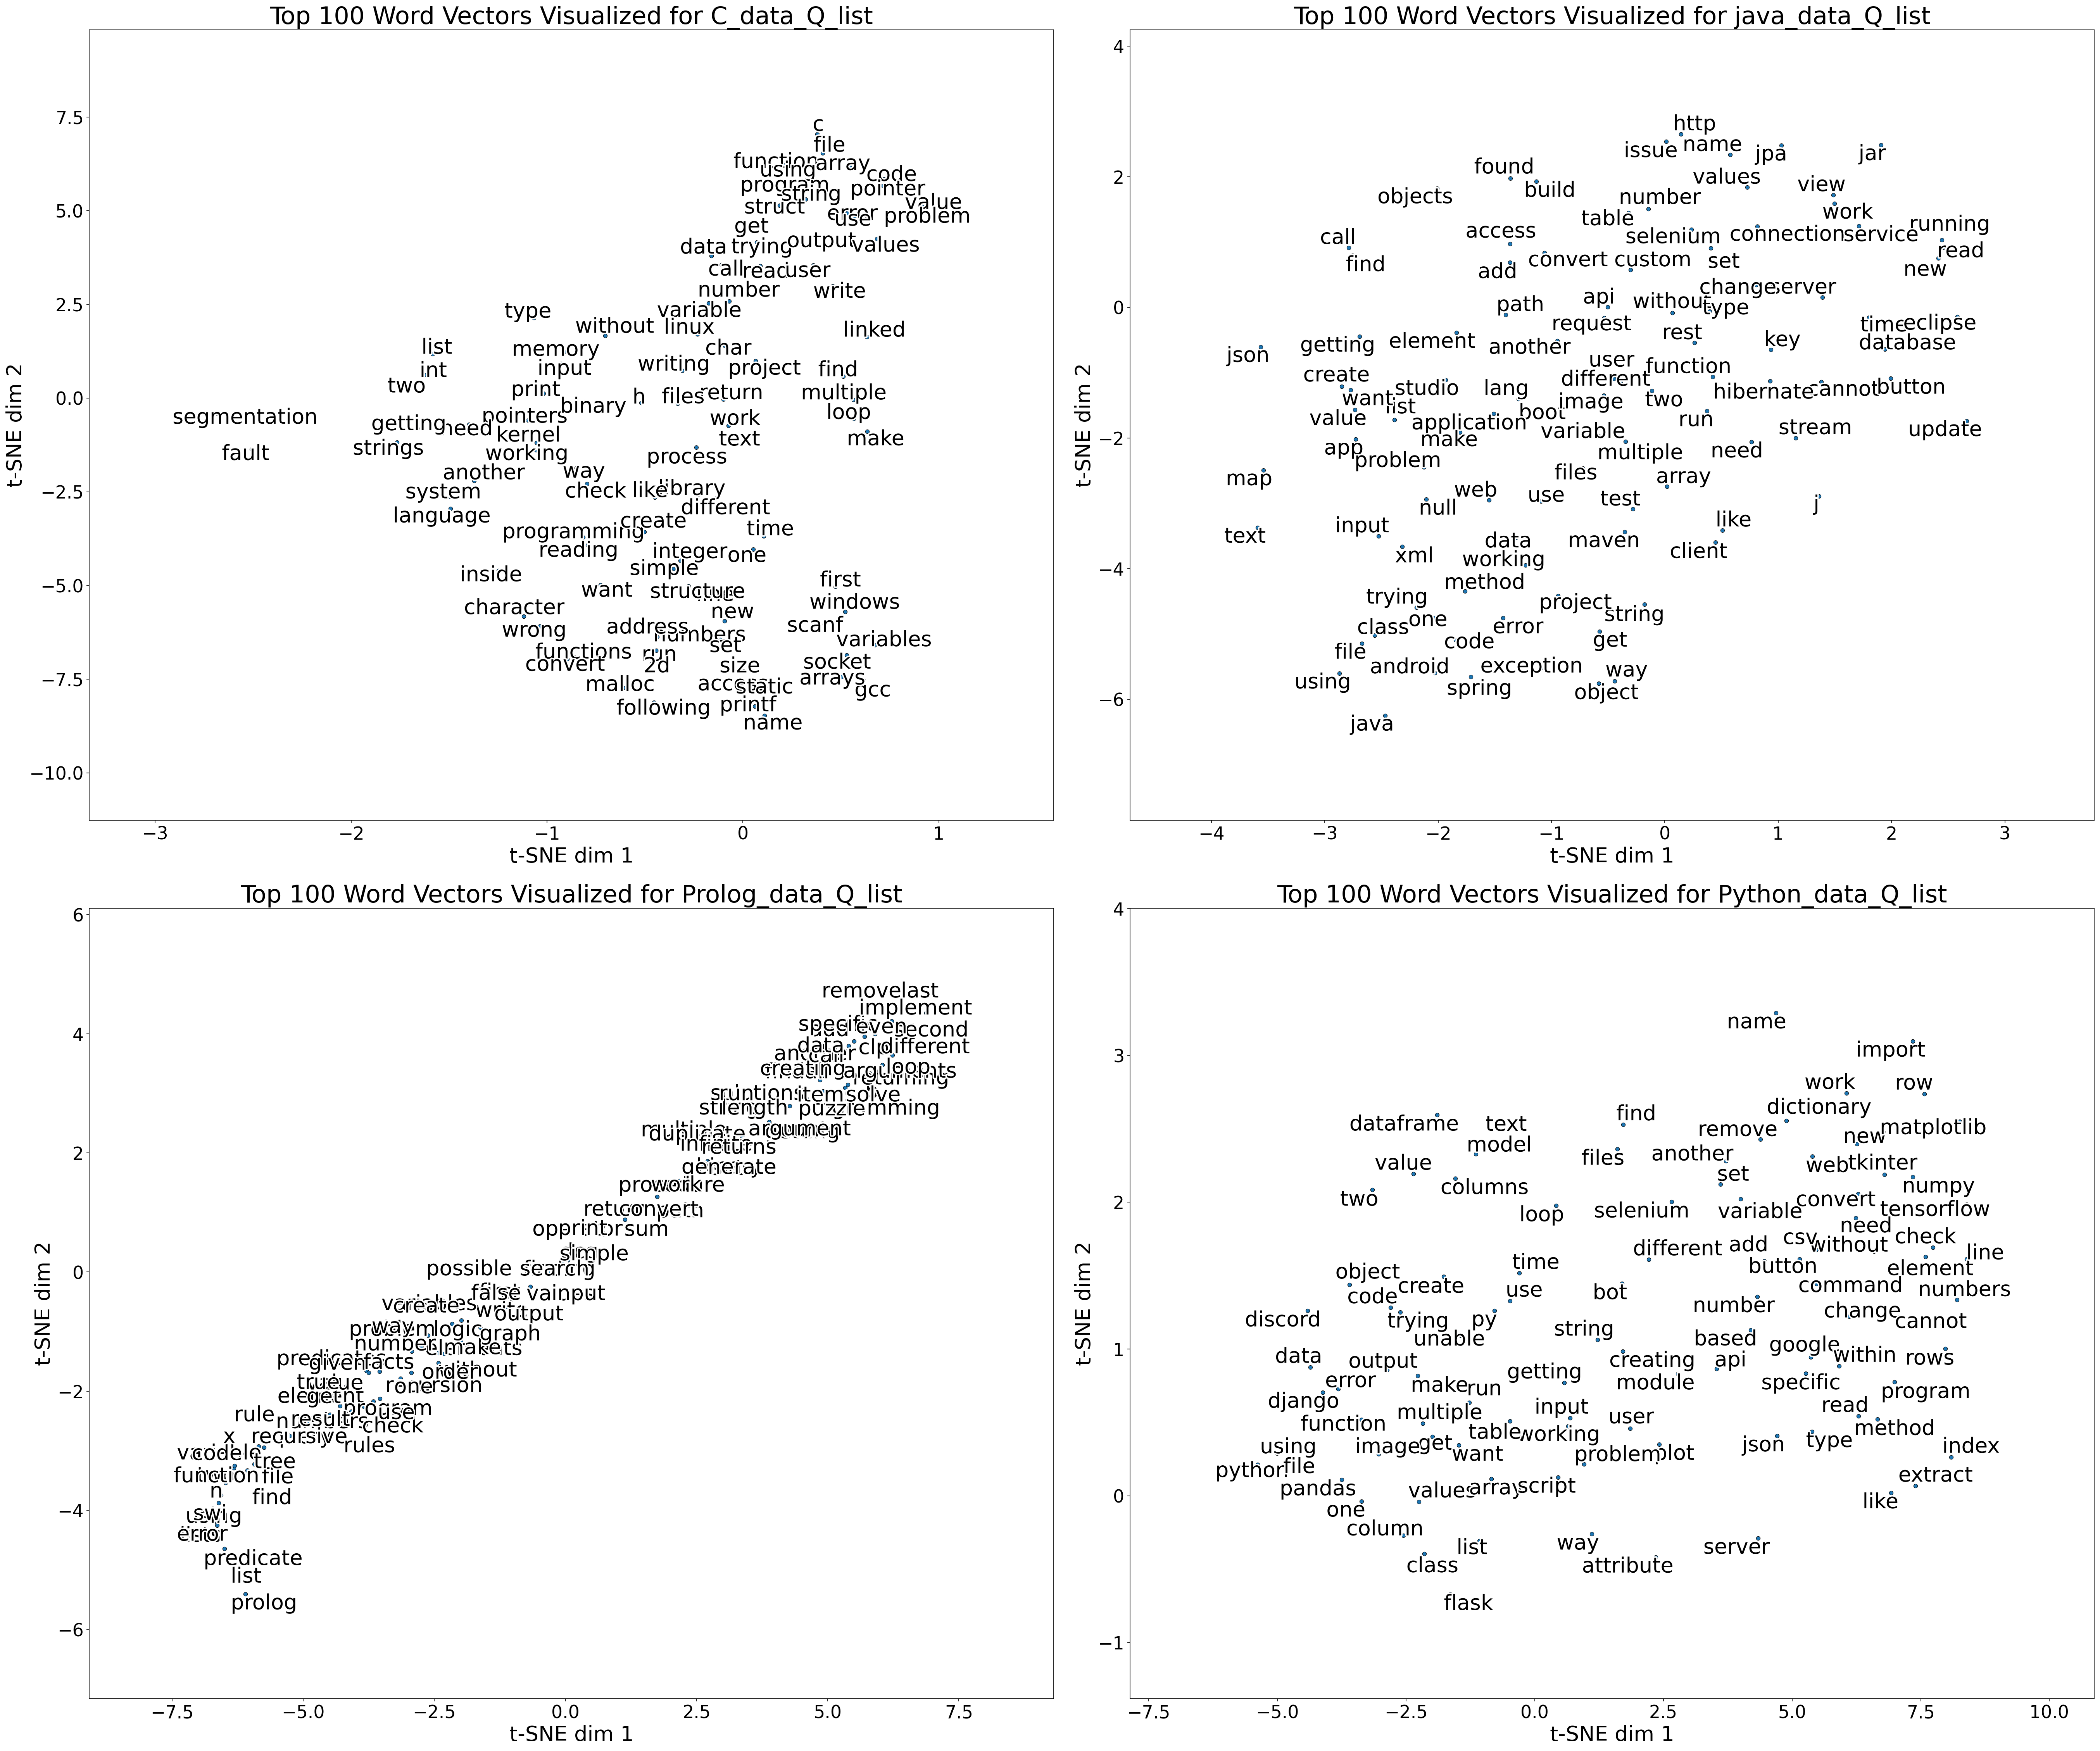

In [ ]:
# ============================================================
# Figure 1 (Final – Larger & Clean Text)
# ============================================================

import os
import re
import sys
import subprocess
import numpy as np

from gensim.models import Word2Vec
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# install adjustText if needed
try:
    from adjustText import adjust_text
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "adjustText"])
    from adjustText import adjust_text

# -----------------------------
# Data directory
# -----------------------------
directory_path = '/content/drive/MyDrive/four programming/four programming_Q_list'

# -----------------------------
# Stopwords
# -----------------------------
stop_words = set(stopwords.words('english'))

# -----------------------------
# Preprocessing (remove numbers)
# -----------------------------
def preprocess_text(text: str):
    text = re.sub(r'\W', ' ', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [w for w in words if not w.isdigit()]
    return words

# -----------------------------
# Load data
# -----------------------------
languages_texts = {}
for filename in os.listdir(directory_path):
    if filename.endswith(".txt"):
        with open(os.path.join(directory_path, filename), 'r', encoding='utf-8') as f:
            languages_texts[filename.replace(".txt", "")] = preprocess_text(f.read())

preferred_order = [
    "C_data_Q_list",
    "java_data_Q_list",
    "Prolog_data_Q_list",
    "Python_data_Q_list"
]
ordered_languages = [k for k in preferred_order if k in languages_texts]

# -----------------------------
# Rendering (clean & paper-safe)
# -----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 150,
    "savefig.dpi": 600,

    "font.size": 24,
    "axes.titlesize": 30,
    "axes.labelsize": 26,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22
})

# -----------------------------
# Parameters
# -----------------------------
TOP_N_WORDS = 100
RANDOM_SEED = 0

LABEL_FONTSIZE = 26      # ★ 더 크게
POINT_SIZE = 24

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(36, 30), constrained_layout=True)
axes = axes.flatten()

# -----------------------------
# Plot
# -----------------------------
for ax_i, language in enumerate(ordered_languages):
    tokens = languages_texts[language]

    model = Word2Vec(
        sentences=[tokens],
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        seed=RANDOM_SEED
    )

    top_words = model.wv.index_to_key[:TOP_N_WORDS]
    vectors = np.array([model.wv[w] for w in top_words])

    perplexity = min(30, max(5, (len(vectors) - 1) // 3))
    coords = TSNE(
        n_components=2,
        random_state=RANDOM_SEED,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        early_exaggeration=18
    ).fit_transform(vectors)

    ax = axes[ax_i]
    ax.scatter(coords[:, 0], coords[:, 1],
               s=POINT_SIZE, edgecolors="black", linewidths=0.5)

    texts = []
    for i, w in enumerate(top_words):
        texts.append(
            ax.text(
                coords[i, 0], coords[i, 1], w,
                fontsize=LABEL_FONTSIZE,
                ha="center", va="center",
                path_effects=[
                    pe.withStroke(linewidth=3.5, foreground="white")
                ]
            )
        )

    adjust_text(
        texts,
        ax=ax,
        only_move={"text": "xy"},
        expand_text=(1.15, 1.25),
        expand_points=(1.10, 1.20),
        force_text=(0.25, 0.35),
        force_points=(0.15, 0.25),
        lim=200
    )

    ax.set_title(f"Top 100 Word Vectors Visualized for {language}")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.grid(False)
    ax.margins(0.18)

# -----------------------------
# Save
# -----------------------------
fig.savefig("Figure1_Word2Vec_TSNE_Top100_2x2_FINAL.pdf", bbox_inches="tight")
fig.savefig("Figure1_Word2Vec_TSNE_Top100_2x2_FINAL.png", dpi=600, bbox_inches="tight")

plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


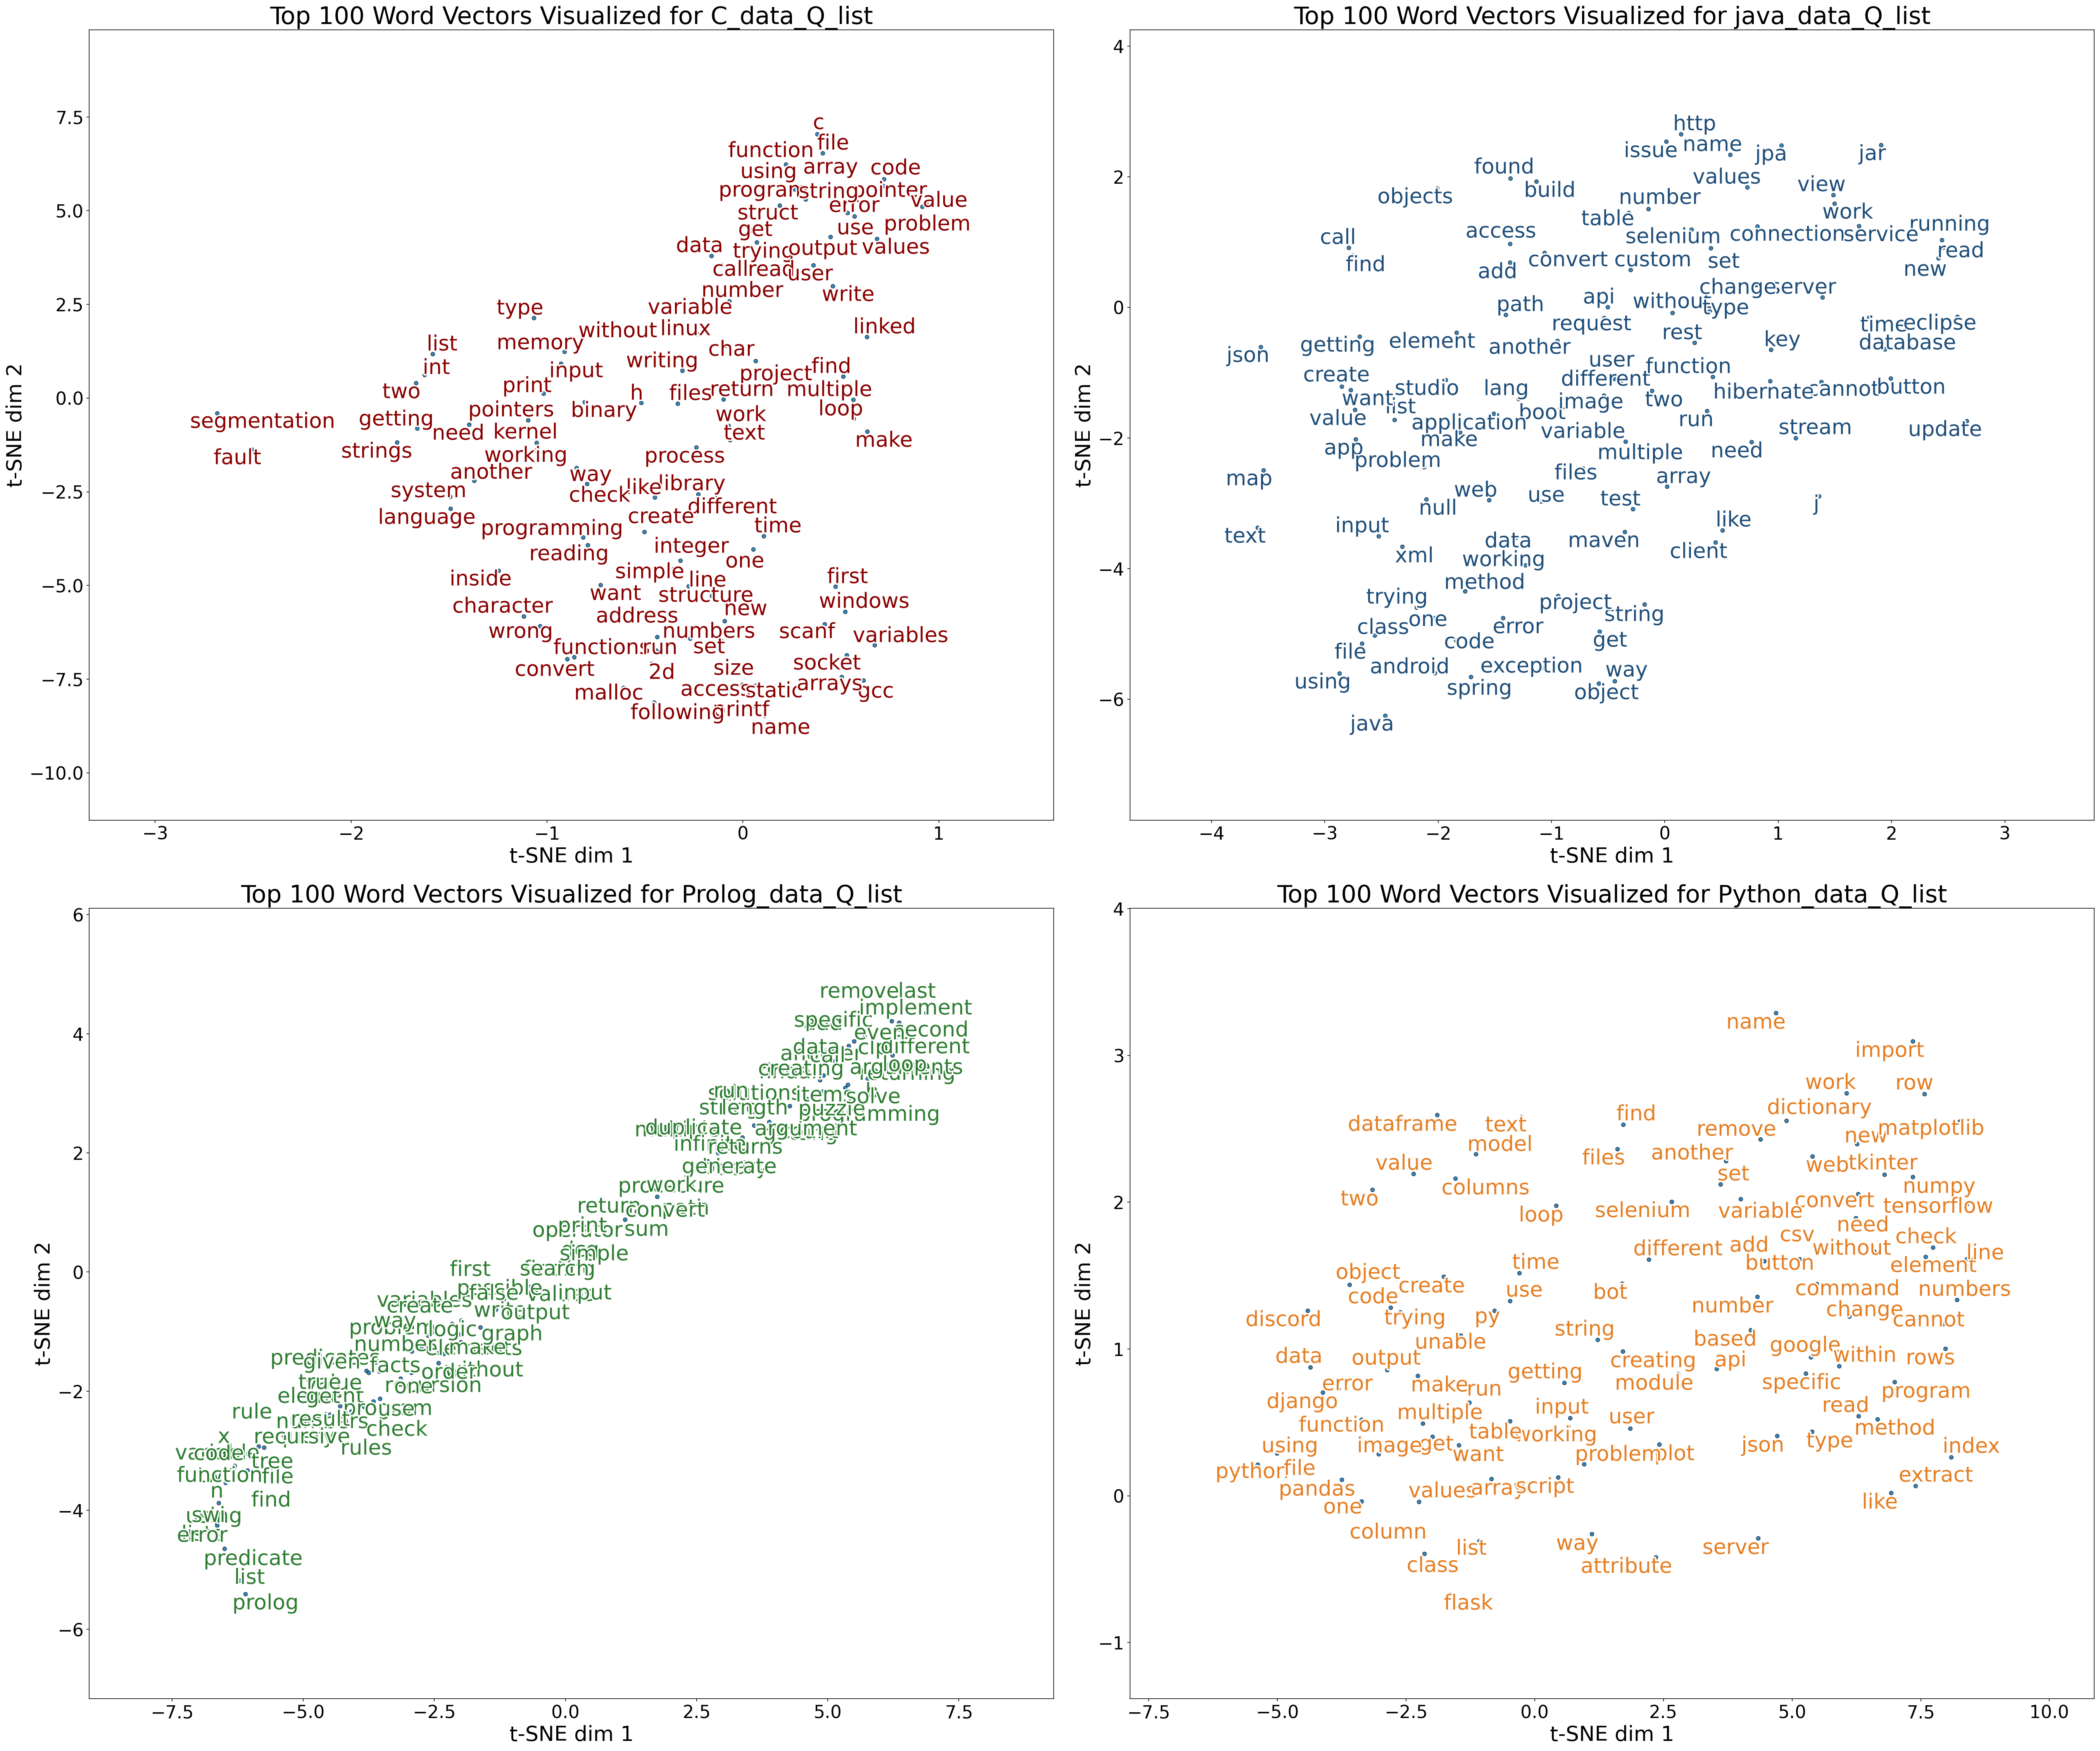

In [ ]:
# ============================================================
# Figure 1 (Final – Larger & Clean Text, Language-wise Colors)
# ============================================================

import os
import re
import sys
import subprocess
import numpy as np

from gensim.models import Word2Vec
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# install adjustText if needed
try:
    from adjustText import adjust_text
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "adjustText"])
    from adjustText import adjust_text

# -----------------------------
# Data directory
# -----------------------------
directory_path = '/content/drive/MyDrive/four programming/four programming_Q_list'

# -----------------------------
# Stopwords
# -----------------------------
stop_words = set(stopwords.words('english'))

# -----------------------------
# Preprocessing (remove numbers)
# -----------------------------
def preprocess_text(text: str):
    text = re.sub(r'\W', ' ', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [w for w in words if not w.isdigit()]
    return words

# -----------------------------
# Load data
# -----------------------------
languages_texts = {}
for filename in os.listdir(directory_path):
    if filename.endswith(".txt"):
        with open(os.path.join(directory_path, filename), 'r', encoding='utf-8') as f:
            languages_texts[filename.replace(".txt", "")] = preprocess_text(f.read())

preferred_order = [
    "C_data_Q_list",
    "java_data_Q_list",
    "Prolog_data_Q_list",
    "Python_data_Q_list"
]
ordered_languages = [k for k in preferred_order if k in languages_texts]

# -----------------------------
# Language-wise color mapping (paper-safe)
# -----------------------------
LANGUAGE_COLORS = {
    "C_data_Q_list": "#8B0000",       # Dark Red
    "java_data_Q_list": "#1F4E79",    # Dark Blue
    "Prolog_data_Q_list": "#2E7D32",  # Dark Green
    "Python_data_Q_list": "#E67E22"   # Dark Orange
}

# -----------------------------
# Rendering (clean & paper-safe)
# -----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 150,
    "savefig.dpi": 600,

    "font.size": 24,
    "axes.titlesize": 30,
    "axes.labelsize": 26,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22
})

# -----------------------------
# Parameters
# -----------------------------
TOP_N_WORDS = 100
RANDOM_SEED = 0

LABEL_FONTSIZE = 26
POINT_SIZE = 24

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(36, 30), constrained_layout=True)
axes = axes.flatten()

# -----------------------------
# Plot
# -----------------------------
for ax_i, language in enumerate(ordered_languages):
    tokens = languages_texts[language]
    label_color = LANGUAGE_COLORS.get(language, "black")

    model = Word2Vec(
        sentences=[tokens],
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        seed=RANDOM_SEED
    )

    top_words = model.wv.index_to_key[:TOP_N_WORDS]
    vectors = np.array([model.wv[w] for w in top_words])

    perplexity = min(30, max(5, (len(vectors) - 1) // 3))
    coords = TSNE(
        n_components=2,
        random_state=RANDOM_SEED,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        early_exaggeration=18
    ).fit_transform(vectors)

    ax = axes[ax_i]
    ax.scatter(
        coords[:, 0], coords[:, 1],
        s=POINT_SIZE,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9
    )

    texts = []
    for i, w in enumerate(top_words):
        texts.append(
            ax.text(
                coords[i, 0], coords[i, 1], w,
                fontsize=LABEL_FONTSIZE,
                ha="center",
                va="center",
                color=label_color,   # ★ 언어별 색상
                path_effects=[
                    pe.withStroke(linewidth=3.5, foreground="white")
                ]
            )
        )

    adjust_text(
        texts,
        ax=ax,
        only_move={"text": "xy"},
        expand_text=(1.15, 1.25),
        expand_points=(1.10, 1.20),
        force_text=(0.25, 0.35),
        force_points=(0.15, 0.25),
        lim=200
    )

    ax.set_title(f"Top 100 Word Vectors Visualized for {language}")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.grid(False)
    ax.margins(0.18)

# -----------------------------
# Save
# -----------------------------
fig.savefig("Figure1_Word2Vec_TSNE_Top100_2x2_color.pdf", bbox_inches="tight")
fig.savefig("Figure1_Word2Vec_TSNE_Top100_2x2_color.png", dpi=600, bbox_inches="tight")

plt.show()

**Figure 2. Distribution of Stack Overflow questions containing predefined problem-solving–related keywords across four programming languages**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-956498995.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(question_counts.index, rotation=45)
/tmp/ipython-input-956498995.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(question_counts_sorted.index, rotation=45)


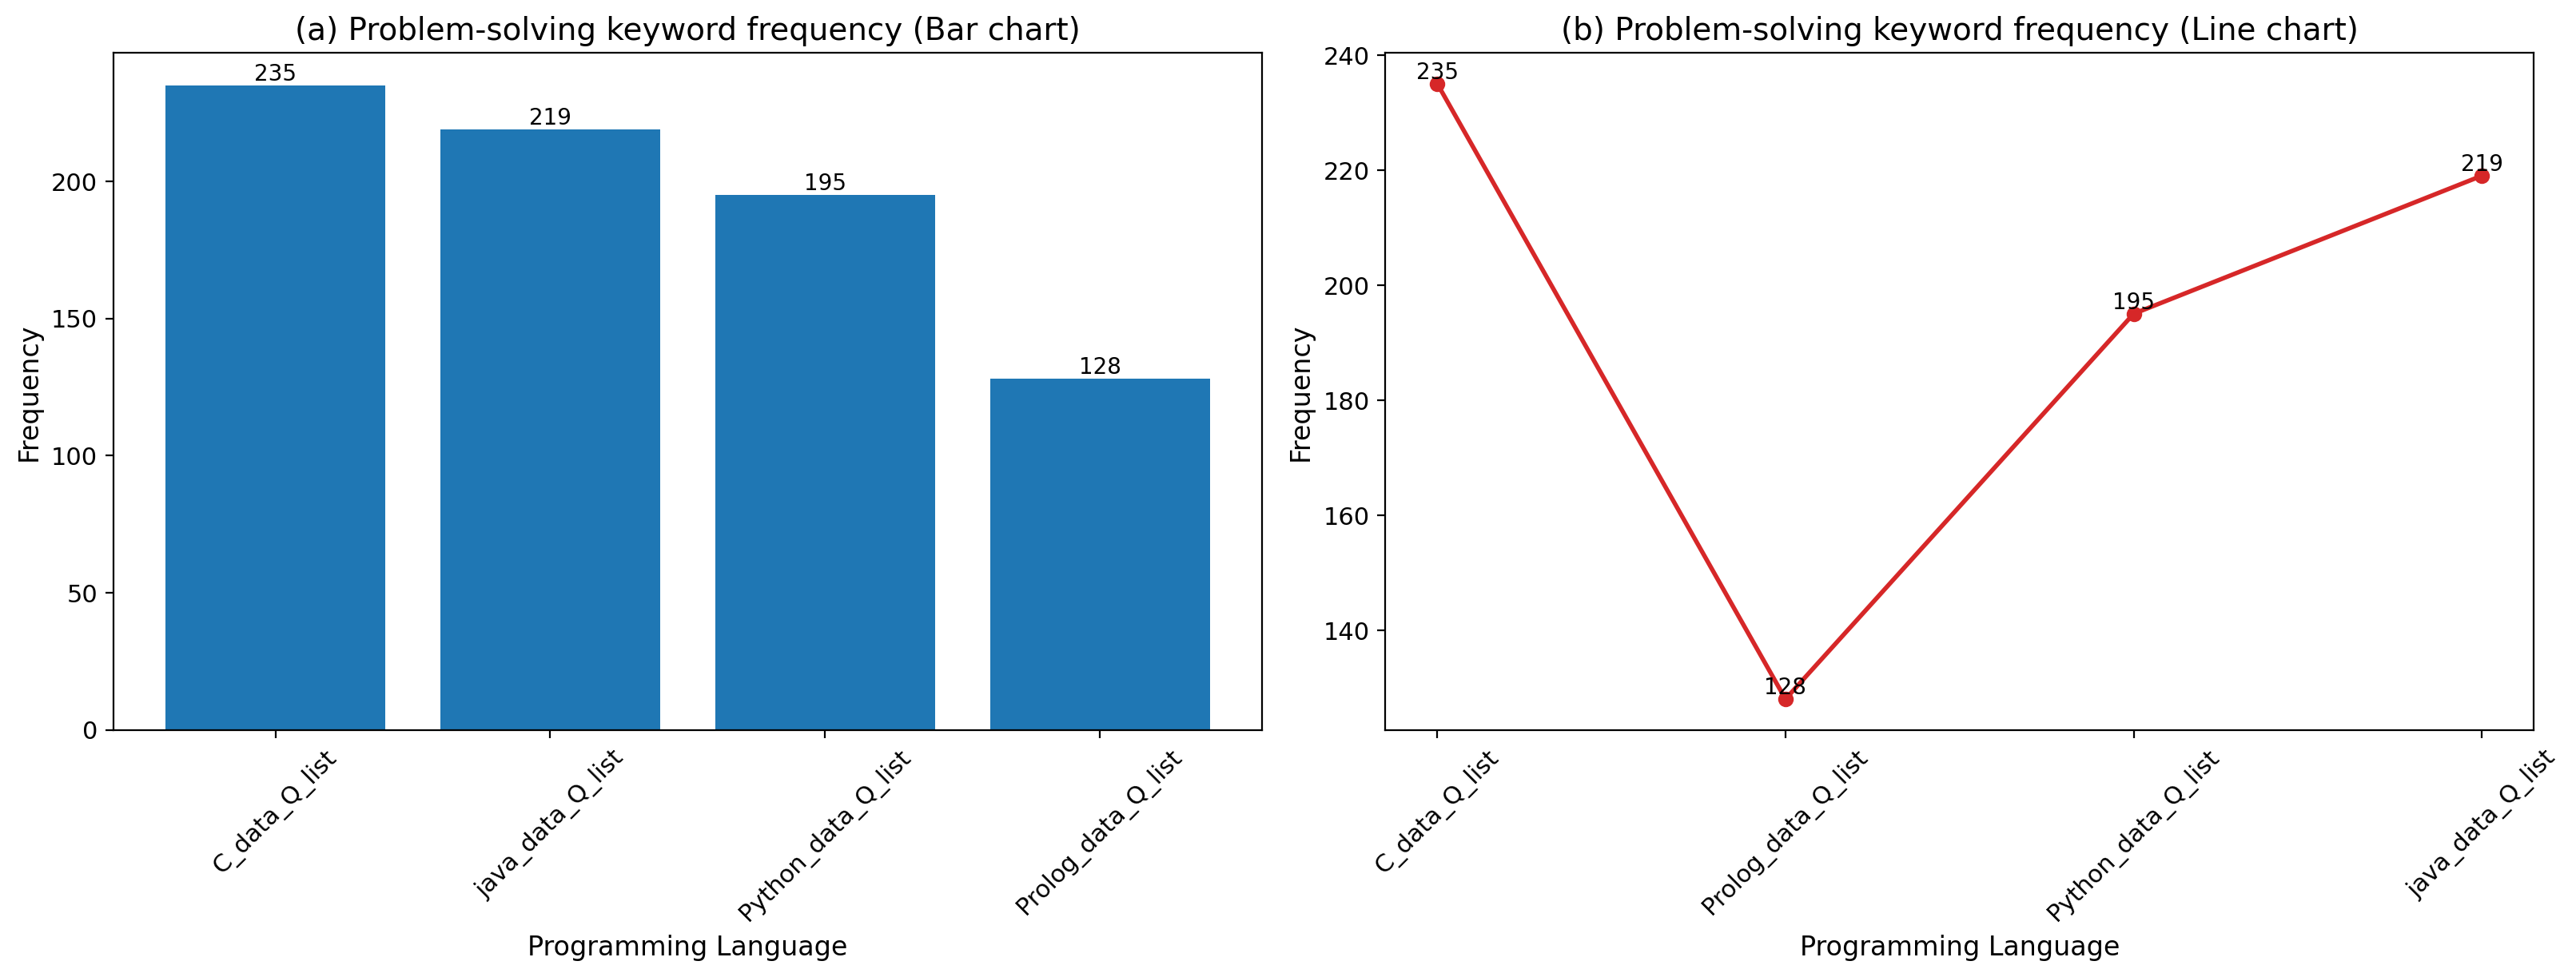

Saved files:
/content/drive/MyDrive/four programming/figures/Figure_ProblemSolving_Keyword_Frequency_Bar_Line.pdf
/content/drive/MyDrive/four programming/figures/Figure_ProblemSolving_Keyword_Frequency_Bar_Line_600dpi.png


In [ ]:
# ==================================================
# Problem-solving keyword frequency visualization
# - Data source: questions.xlsx (Google Drive)
# - Two-panel figure:
#   (a) Bar chart
#   (b) Line chart
# - High-resolution export (PDF + 600 dpi PNG)
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import drive

# --------------------------------------------------
# 0) Mount Google Drive
# --------------------------------------------------
drive.mount('/content/drive')

# --------------------------------------------------
# 1) Read Excel file
# --------------------------------------------------
def read_questions_from_excel(file_path):
    return pd.read_excel(file_path)

# --------------------------------------------------
# 2) Plot side-by-side graphs
# --------------------------------------------------
def plot_questions_by_language_side_by_side(df):

    # Count questions by programming language
    question_counts = df['Programming Language'].value_counts()
    question_counts_sorted = question_counts.sort_index()

    # Journal-quality settings (MDPI)
    plt.rcParams.update({
        "figure.dpi": 200,      # display in notebook
        "savefig.dpi": 600,     # publication quality
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11
    })

    # Create 1x2 figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    # --------------------------------------------------
    # (a) Bar chart
    # --------------------------------------------------
    ax1 = axes[0]
    bars = ax1.bar(
        question_counts.index,
        question_counts.values,
        color='tab:blue'
    )

    ax1.set_title('(a) Problem-solving keyword frequency (Bar chart)')
    ax1.set_xlabel('Programming Language')
    ax1.set_ylabel('Frequency')
    ax1.set_xticklabels(question_counts.index, rotation=45)

    # Add value labels
    for bar in bars:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{int(bar.get_height())}',
            ha='center',
            va='bottom',
            fontsize=10
        )

    # --------------------------------------------------
    # (b) Line chart
    # --------------------------------------------------
    ax2 = axes[1]
    ax2.plot(
        question_counts_sorted.index,
        question_counts_sorted.values,
        marker='o',
        linestyle='-',
        linewidth=2,
        color='tab:red'
    )

    ax2.set_title('(b) Problem-solving keyword frequency (Line chart)')
    ax2.set_xlabel('Programming Language')
    ax2.set_ylabel('Frequency')
    ax2.set_xticklabels(question_counts_sorted.index, rotation=45)

    # Add value labels
    for i, v in enumerate(question_counts_sorted.values):
        ax2.text(
            i,
            v,
            str(v),
            ha='center',
            va='bottom',
            fontsize=10
        )

    # --------------------------------------------------
    # 3) Save figures
    # --------------------------------------------------
    save_dir = '/content/drive/MyDrive/four programming/figures'
    os.makedirs(save_dir, exist_ok=True)

    pdf_path = os.path.join(
        save_dir,
        'Figure_ProblemSolving_Keyword_Frequency_Bar_Line.pdf'
    )
    png_path = os.path.join(
        save_dir,
        'Figure_ProblemSolving_Keyword_Frequency_Bar_Line_600dpi.png'
    )

    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=600, bbox_inches='tight')

    plt.show()

    print("Saved files:")
    print(pdf_path)
    print(png_path)

# --------------------------------------------------
# 4) Execute
# --------------------------------------------------
file_path = '/content/drive/MyDrive/four programming/questions.xlsx'

df = read_questions_from_excel(file_path)
plot_questions_by_language_side_by_side(df)

**Table 6. Sample Stack Overflow questions and corresponding text-based complexity scores across programming languages**

In [ ]:
import re
import csv
import os
from difflib import get_close_matches

# -----------------------------
# 0) Parameters
# -----------------------------
W_LENGTH = 0.5
W_WORDS  = 0.3
W_AVGWL  = 0.2
TOKEN_PATTERN = r'\w+'

save_dir  = '/content/drive/MyDrive/four programming/results'
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# 1) Language files
# -----------------------------
lang_files = {
    "C":      "/content/drive/MyDrive/four programming/four programming_Q_list/C_data_Q_list.txt",
    "Java":   "/content/drive/MyDrive/four programming/four programming_Q_list/java_data_Q_list.txt",
    "Python": "/content/drive/MyDrive/four programming/four programming_Q_list/Python_data_Q_list.txt",
    "Prolog": "/content/drive/MyDrive/four programming/four programming_Q_list/Prolog_data_Q_list.txt",
}

# -----------------------------
# 2) Targets (worked examples)
#    - 앞뒤 공백/대소문자 차이는 자동 보정
# -----------------------------
targets = {
    "C":      "Cannot display all the element of my array in C?",
    "Java":   "My app is crashing after I clicked the call button I am a starter in Android Studio, my app works fine but crashes every time I click the call button",
    "Python": "Plotting whole month in Python with only 1 day data",
    "Prolog": "What is a simple way to find the max length of a list in prolog?",
}

# -----------------------------
# Helpers
# -----------------------------
def minmax_normalize(values):
    vmin, vmax = min(values), max(values)
    if vmax == vmin:
        return [0.0 for _ in values]
    return [(v - vmin) / (vmax - vmin) for v in values]

def clean_text(s: str) -> str:
    """Normalize whitespace + lowercase for robust matching."""
    s = s.strip().lower()
    s = re.sub(r'\s+', ' ', s)  # multiple spaces -> single
    return s

def find_best_match(questions, target):
    """
    1) exact match on cleaned text
    2) contains match (either direction)
    3) difflib close match (best effort)
    Returns: (matched_question, match_type) or (None, None)
    """
    if not target:
        return None, None

    target_c = clean_text(target)
    q_map = {clean_text(q): q for q in questions}  # cleaned -> original

    # (1) exact cleaned match
    if target_c in q_map:
        return q_map[target_c], "exact(cleaned)"

    # (2) contains match: target in question OR question in target
    for q in questions:
        qc = clean_text(q)
        if target_c in qc or qc in target_c:
            return q, "contains"

    # (3) close match (difflib)
    candidates = get_close_matches(target_c, list(q_map.keys()), n=1, cutoff=0.6)
    if candidates:
        return q_map[candidates[0]], "close_match(difflib)"

    return None, None


# -----------------------------
# Run for each language
# -----------------------------
for LANGUAGE_NAME, file_path in lang_files.items():

    # 1) Read file
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # 2) Feature extraction
    questions = []
    L_list, W_list, A_list = [], [], []

    for line in lines:
        q = line.strip()
        if not q:
            continue

        length_score = len(q)
        words = re.findall(TOKEN_PATTERN, q)
        word_count = len(words)
        avg_word_length = sum(len(w) for w in words) / word_count if word_count > 0 else 0.0

        questions.append(q)
        L_list.append(length_score)
        W_list.append(word_count)
        A_list.append(avg_word_length)

    # 3) Min–max normalization
    L_norm = minmax_normalize(L_list)
    W_norm = minmax_normalize(W_list)
    A_norm = minmax_normalize(A_list)

    # 4) Complexity score
    difficulties = []
    for i in range(len(questions)):
        score = (
            W_LENGTH * L_norm[i] +
            W_WORDS  * W_norm[i] +
            W_AVGWL  * A_norm[i]
        )
        difficulties.append(score)

    average_difficulty = sum(difficulties) / len(difficulties) if difficulties else 0.0

    # 4.1) Corpus min/max 출력
    Lmin, Lmax = min(L_list), max(L_list)
    Wmin, Wmax = min(W_list), max(W_list)
    Amin, Amax = min(A_list), max(A_list)

    print("\n" + "="*60)
    print(f"=== Corpus min/max ({LANGUAGE_NAME}) ===")
    print("Lmin,Lmax =", Lmin, Lmax)
    print("Wmin,Wmax =", Wmin, Wmax)
    print("Amin,Amax =", Amin, Amax)
    print("Average difficulty (raw 0-1) =", average_difficulty)
    print("Average difficulty (x100)    =", average_difficulty * 100)

    # 4.2) Worked example (robust match)
    target = targets.get(LANGUAGE_NAME)
    if target:
        matched_q, match_type = find_best_match(questions, target)

        if matched_q is None:
            print("\n[NOT FOUND] target sentence not matched (even with robust matching).")
            print("Target was:")
            print("-", target)
        else:
            # Find matched_q index to fetch precomputed stats
            idx = questions.index(matched_q)

            L = L_list[idx]
            W = W_list[idx]
            A = A_list[idx]
            Ln = L_norm[idx]
            Wn = W_norm[idx]
            An = A_norm[idx]
            S  = difficulties[idx]

            print(f"\n=== Worked example (target question) [{LANGUAGE_NAME}] ===")
            print(f"(match type: {match_type})")
            print("q =", matched_q)

            print("\n[1] Raw values")
            print("  L(q) =", L)
            print("  W(q) =", W)
            print("  A(q) =", A)

            print("\n[2] Min-max normalization")
            print(f"  L_norm(q) = ({L} - {Lmin}) / ({Lmax} - {Lmin}) = {Ln}")
            print(f"  W_norm(q) = ({W} - {Wmin}) / ({Wmax} - {Wmin}) = {Wn}")
            print(f"  A_norm(q) = ({A} - {Amin}) / ({Amax} - {Amin}) = {An}")

            print("\n[3] Weighted sum score")
            print(f"  S(q) = 0.5*{Ln} + 0.3*{Wn} + 0.2*{An} = {S}")
            print(f"  S(q) x 100 = {S * 100}")

    # 5) Save to CSV (Table 6 ready)
    csv_path = os.path.join(save_dir, f"Table6_TextBasedComplexity_{LANGUAGE_NAME}.csv")
    with open(csv_path, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["Programming Language", "Questionnaires", "Difficulty", "Average Difficulty"])
        for q, d in zip(questions, difficulties):
            writer.writerow([LANGUAGE_NAME, q, round(d, 4), round(average_difficulty, 4)])

    print("CSV saved:", csv_path)


=== Corpus min/max (C) ===
Lmin,Lmax = 15 537
Wmin,Wmax = 2 103
Amin,Amax = 2.090909090909091 12.2
Average difficulty (raw 0-1) = 0.14502709339417832
Average difficulty (x100)    = 14.502709339417832

=== Worked example (target question) [C] ===
(match type: exact(cleaned))
q = Cannot display all the element of my array in C?

[1] Raw values
  L(q) = 48
  W(q) = 10
  A(q) = 3.8

[2] Min-max normalization
  L_norm(q) = (48 - 15) / (537 - 15) = 0.06321839080459771
  W_norm(q) = (10 - 2) / (103 - 2) = 0.07920792079207921
  A_norm(q) = (3.8 - 2.090909090909091) / (12.2 - 2.090909090909091) = 0.16906474820143882

[3] Weighted sum score
  S(q) = 0.5*0.06321839080459771 + 0.3*0.07920792079207921 + 0.2*0.16906474820143882 = 0.08918452128021039
  S(q) x 100 = 8.91845212802104
CSV saved: /content/drive/MyDrive/four programming/results/Table6_TextBasedComplexity_C.csv

=== Corpus min/max (Java) ===
Lmin,Lmax = 16 684
Wmin,Wmax = 2 135
Amin,Amax = 2.230769230769231 11.0
Average difficulty (raw 0-

In [ ]:
import re
import csv
import os
from difflib import get_close_matches

# -----------------------------
# 0) Parameters
# -----------------------------
W_LENGTH = 0.5
W_WORDS  = 0.3
W_AVGWL  = 0.2
TOKEN_PATTERN = r'\w+'

save_dir  = '/content/drive/MyDrive/four programming/results'
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# 1) Language files
# -----------------------------
lang_files = {
    "C":      "/content/drive/MyDrive/four programming/four programming_Q_list/C_data_Q_list.txt",
    "Java":   "/content/drive/MyDrive/four programming/four programming_Q_list/java_data_Q_list.txt",
    "Python": "/content/drive/MyDrive/four programming/four programming_Q_list/Python_data_Q_list.txt",
    "Prolog": "/content/drive/MyDrive/four programming/four programming_Q_list/Prolog_data_Q_list.txt",
}

# -----------------------------
# 2) Targets (worked examples)
#    - 앞뒤 공백/대소문자 차이는 자동 보정
# -----------------------------
targets = {
    "C":      "Determine pointer length in a typedef struct [du-plicate] How to determine pointer length in a typedef struct?",
    "Java":   "Browser requests a file larger than the original file size. I am creating a video play function on my website.",
    "Python": "How can I access the value in nested dictionary using a single key?",
    "Prolog": "Return the list of users in prolog",
}

# -----------------------------
# Helpers
# -----------------------------
def minmax_normalize(values):
    vmin, vmax = min(values), max(values)
    if vmax == vmin:
        return [0.0 for _ in values]
    return [(v - vmin) / (vmax - vmin) for v in values]

def clean_text(s: str) -> str:
    """Normalize whitespace + lowercase for robust matching."""
    s = s.strip().lower()
    s = re.sub(r'\s+', ' ', s)  # multiple spaces -> single
    return s

def find_best_match(questions, target):
    """
    1) exact match on cleaned text
    2) contains match (either direction)
    3) difflib close match (best effort)
    Returns: (matched_question, match_type) or (None, None)
    """
    if not target:
        return None, None

    target_c = clean_text(target)
    q_map = {clean_text(q): q for q in questions}  # cleaned -> original

    # (1) exact cleaned match
    if target_c in q_map:
        return q_map[target_c], "exact(cleaned)"

    # (2) contains match: target in question OR question in target
    for q in questions:
        qc = clean_text(q)
        if target_c in qc or qc in target_c:
            return q, "contains"

    # (3) close match (difflib)
    candidates = get_close_matches(target_c, list(q_map.keys()), n=1, cutoff=0.6)
    if candidates:
        return q_map[candidates[0]], "close_match(difflib)"

    return None, None


# -----------------------------
# Run for each language
# -----------------------------
for LANGUAGE_NAME, file_path in lang_files.items():

    # 1) Read file
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # 2) Feature extraction
    questions = []
    L_list, W_list, A_list = [], [], []

    for line in lines:
        q = line.strip()
        if not q:
            continue

        length_score = len(q)
        words = re.findall(TOKEN_PATTERN, q)
        word_count = len(words)
        avg_word_length = sum(len(w) for w in words) / word_count if word_count > 0 else 0.0

        questions.append(q)
        L_list.append(length_score)
        W_list.append(word_count)
        A_list.append(avg_word_length)

    # 3) Min–max normalization
    L_norm = minmax_normalize(L_list)
    W_norm = minmax_normalize(W_list)
    A_norm = minmax_normalize(A_list)

    # 4) Complexity score
    difficulties = []
    for i in range(len(questions)):
        score = (
            W_LENGTH * L_norm[i] +
            W_WORDS  * W_norm[i] +
            W_AVGWL  * A_norm[i]
        )
        difficulties.append(score)

    average_difficulty = sum(difficulties) / len(difficulties) if difficulties else 0.0

    # 4.1) Corpus min/max 출력
    Lmin, Lmax = min(L_list), max(L_list)
    Wmin, Wmax = min(W_list), max(W_list)
    Amin, Amax = min(A_list), max(A_list)

    print("\n" + "="*60)
    print(f"=== Corpus min/max ({LANGUAGE_NAME}) ===")
    print("Lmin,Lmax =", Lmin, Lmax)
    print("Wmin,Wmax =", Wmin, Wmax)
    print("Amin,Amax =", Amin, Amax)
    print("Average difficulty (raw 0-1) =", average_difficulty)
    print("Average difficulty (x100)    =", average_difficulty * 100)

    # 4.2) Worked example (robust match)
    target = targets.get(LANGUAGE_NAME)
    if target:
        matched_q, match_type = find_best_match(questions, target)

        if matched_q is None:
            print("\n[NOT FOUND] target sentence not matched (even with robust matching).")
            print("Target was:")
            print("-", target)
        else:
            # Find matched_q index to fetch precomputed stats
            idx = questions.index(matched_q)

            L = L_list[idx]
            W = W_list[idx]
            A = A_list[idx]
            Ln = L_norm[idx]
            Wn = W_norm[idx]
            An = A_norm[idx]
            S  = difficulties[idx]

            print(f"\n=== Worked example (target question) [{LANGUAGE_NAME}] ===")
            print(f"(match type: {match_type})")
            print("q =", matched_q)

            print("\n[1] Raw values")
            print("  L(q) =", L)
            print("  W(q) =", W)
            print("  A(q) =", A)

            print("\n[2] Min-max normalization")
            print(f"  L_norm(q) = ({L} - {Lmin}) / ({Lmax} - {Lmin}) = {Ln}")
            print(f"  W_norm(q) = ({W} - {Wmin}) / ({Wmax} - {Wmin}) = {Wn}")
            print(f"  A_norm(q) = ({A} - {Amin}) / ({Amax} - {Amin}) = {An}")

            print("\n[3] Weighted sum score")
            print(f"  S(q) = 0.5*{Ln} + 0.3*{Wn} + 0.2*{An} = {S}")
            print(f"  S(q) x 100 = {S * 100}")

    # 5) Save to CSV (Table 6 ready)
    csv_path = os.path.join(save_dir, f"Table6_TextBasedComplexity_{LANGUAGE_NAME}.csv")
    with open(csv_path, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["Programming Language", "Questionnaires", "Difficulty", "Average Difficulty"])
        for q, d in zip(questions, difficulties):
            writer.writerow([LANGUAGE_NAME, q, round(d, 4), round(average_difficulty, 4)])

    print("CSV saved:", csv_path)


=== Corpus min/max (C) ===
Lmin,Lmax = 15 537
Wmin,Wmax = 2 103
Amin,Amax = 2.090909090909091 12.2
Average difficulty (raw 0-1) = 0.14502709339417832
Average difficulty (x100)    = 14.502709339417832

=== Worked example (target question) [C] ===
(match type: close_match(difflib))
q = determine pointer length in a typedef struct [duplicate] How to determine pointer length in a typedef struct?

[1] Raw values
  L(q) = 109
  W(q) = 17
  A(q) = 5.294117647058823

[2] Min-max normalization
  L_norm(q) = (109 - 15) / (537 - 15) = 0.18007662835249041
  W_norm(q) = (17 - 2) / (103 - 2) = 0.1485148514851485
  A_norm(q) = (5.294117647058823 - 2.090909090909091) / (12.2 - 2.090909090909091) = 0.31686415573423615

[3] Weighted sum score
  S(q) = 0.5*0.18007662835249041 + 0.3*0.1485148514851485 + 0.2*0.31686415573423615 = 0.197965600768637
  S(q) x 100 = 19.7965600768637
CSV saved: /content/drive/MyDrive/four programming/results/Table6_TextBasedComplexity_C.csv

=== Corpus min/max (Java) ===
Lmin,

**Figure 3. Distribution of text-based complexity score ranges for 3,000 Stack Overflow questions per programming language**

**Frequency Distribution of Difficulty Ranges for 3,000 Questions in Each of the Four Programming Languages**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-737558469.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


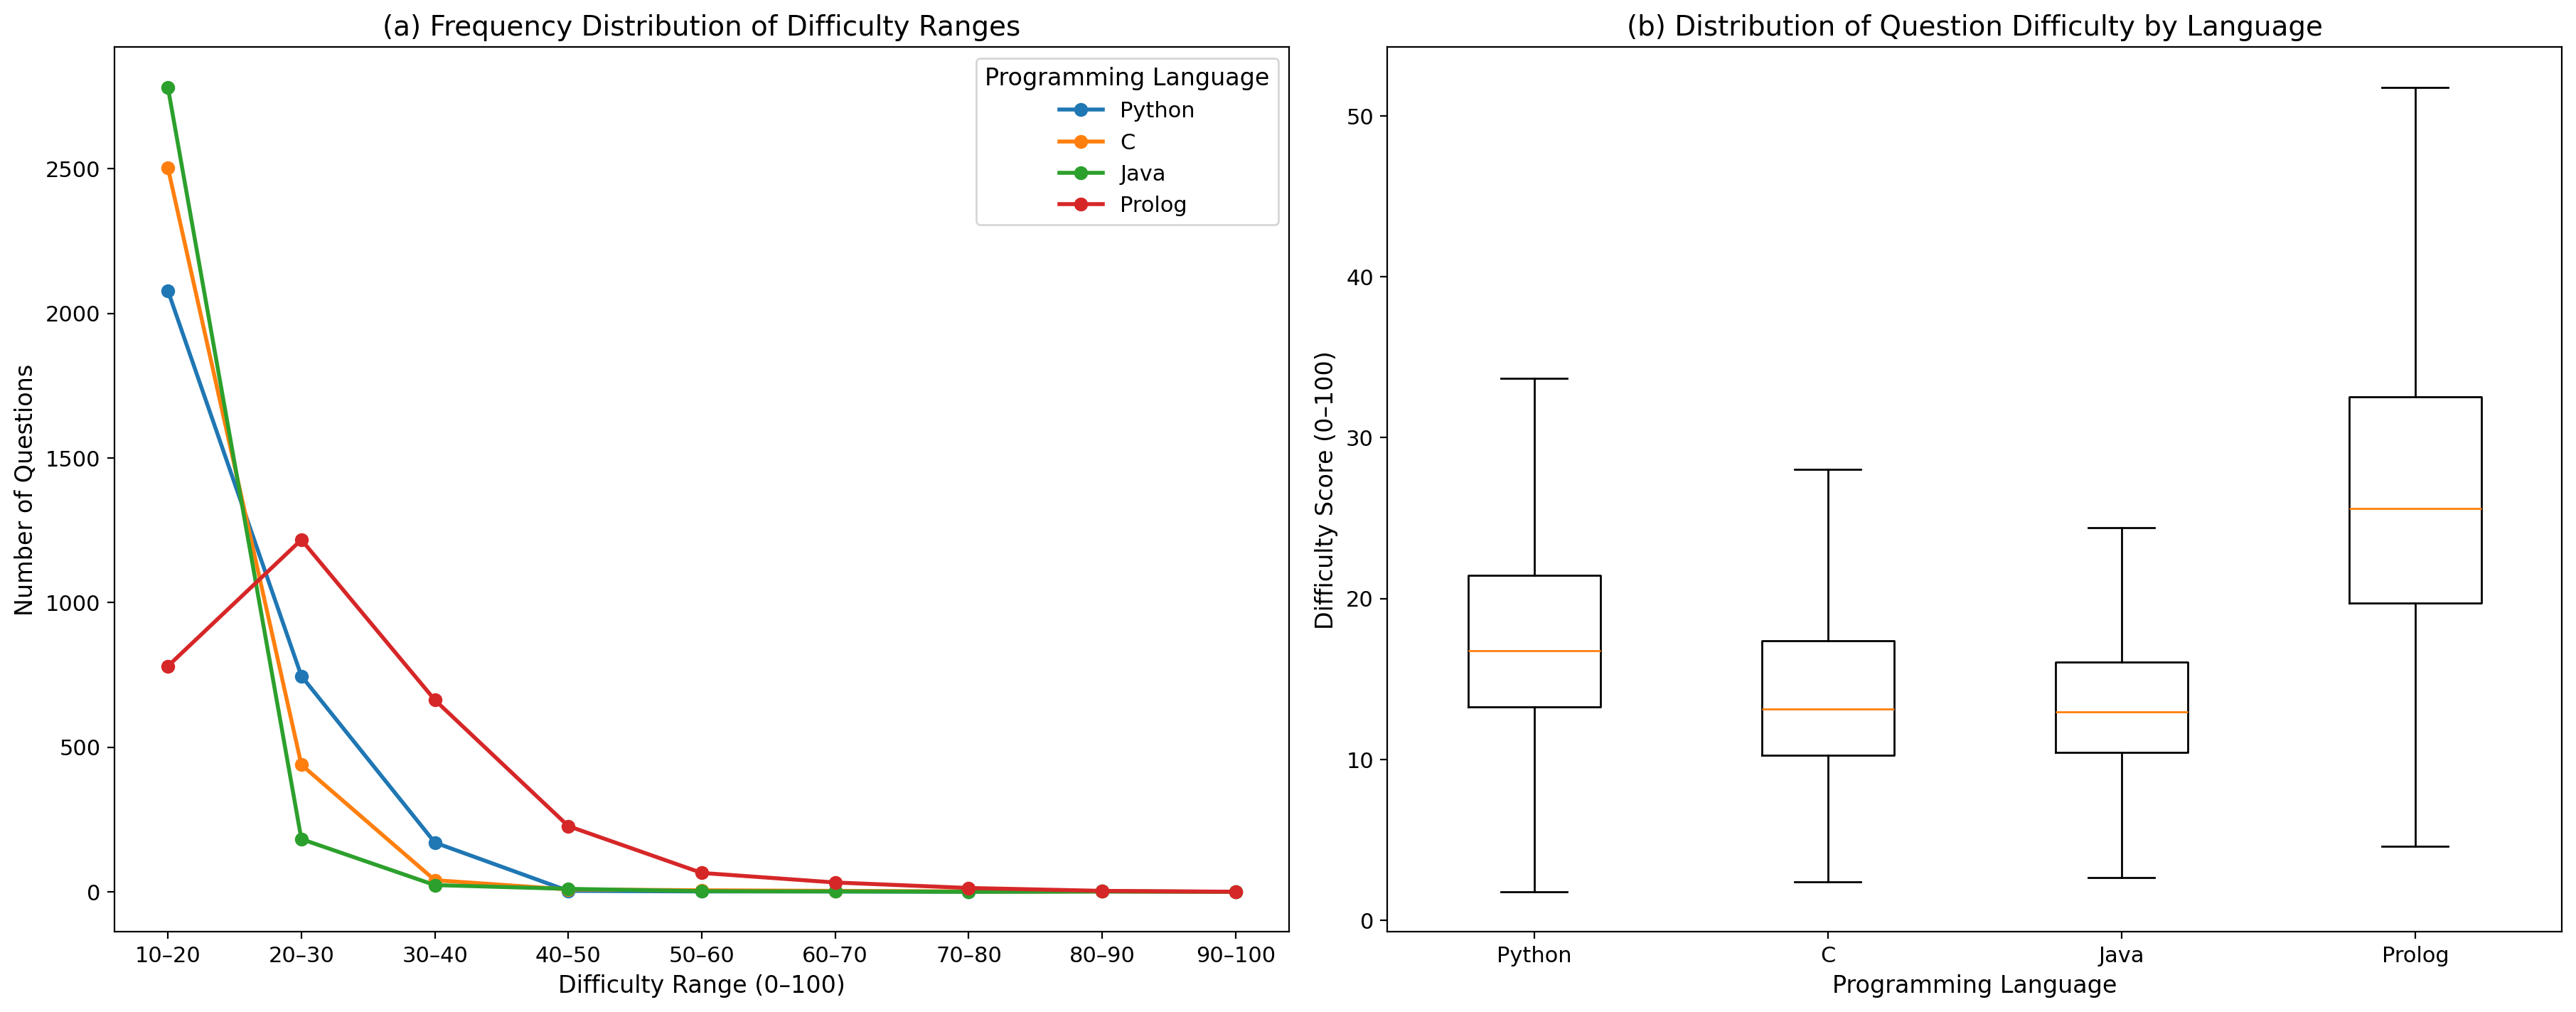

Saved files:
/content/drive/MyDrive/four programming/figures/Figure_Difficulty_Distribution_UPDATED.pdf
/content/drive/MyDrive/four programming/figures/Figure_Difficulty_Distribution_UPDATED_600dpi.png

[Frequency table by range]


,Difficulty Range,Python,C,Java,Prolog
0,10–20,2078,2503,2781,780
1,20–30,746,439,182,1217
2,30–40,170,40,23,663
3,40–50,3,8,10,227
4,50–60,1,5,2,65
5,60–70,1,3,1,32
6,70–80,0,1,0,13
7,80–90,1,1,1,3
8,90–100,0,0,0,0


In [ ]:
# ============================================================
# Figure: Difficulty Distribution (UPDATED)
# - Difficulty ranges: 10–20, ..., 90–100   (EN DASH: U+2013)
# - Languages: Python, C, Java, Prolog
# - Two-panel figure: (a) Line plot, (b) Box plot
# - Input: Table6_TextBasedComplexity_{Language}.csv (Difficulty in 0–1)
# - Output: PDF (vector) + PNG (600 dpi)
# - Saved to Google Drive
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import drive

# ------------------------------------------------------------
# 0) Mount Google Drive
# ------------------------------------------------------------
drive.mount('/content/drive')

# ------------------------------------------------------------
# 1) Load Table 6 CSVs (difficulty per question)
# ------------------------------------------------------------
base_dir = '/content/drive/MyDrive/four programming/results'

files = {
    'Python': os.path.join(base_dir, 'Table6_TextBasedComplexity_Python.csv'),
    'C':      os.path.join(base_dir, 'Table6_TextBasedComplexity_C.csv'),
    'Java':   os.path.join(base_dir, 'Table6_TextBasedComplexity_Java.csv'),
    'Prolog': os.path.join(base_dir, 'Table6_TextBasedComplexity_Prolog.csv')
}

# Difficulty (0–1) -> 0–100
diff_100 = {}
for lang, path in files.items():
    df_lang = pd.read_csv(path)
    # CSV의 Difficulty 컬럼은 0–1 스케일(정규화 점수)
    diff_100[lang] = df_lang['Difficulty'].astype(float) * 100


# ------------------------------------------------------------
# 2) Make frequency table by bins (10–20 ... 90–100)
#    MDPI: use en dash (–, U+2013) between numbers
# ------------------------------------------------------------
bins = [10,20,30,40,50,60,70,80,90,100]

EN_DASH = "\u2013"
labels = [
    f"10{EN_DASH}20",
    f"20{EN_DASH}30",
    f"30{EN_DASH}40",
    f"40{EN_DASH}50",
    f"50{EN_DASH}60",
    f"60{EN_DASH}70",
    f"70{EN_DASH}80",
    f"80{EN_DASH}90",
    f"90{EN_DASH}100",
]

freq = pd.DataFrame({'Difficulty Range': labels})

for lang, series in diff_100.items():
    # right=False: [10,20) ... [90,100)
    # 100 exactly 들어가는 값이 있을 수 있어 안전하게 처리
    s = series.clip(lower=10, upper=99.999999)  # 100은 99.999..로 넣어서 마지막 구간에 포함
    counts = pd.cut(s, bins=bins, labels=labels, right=False).value_counts().sort_index()
    freq[lang] = counts.values

df = freq  # 기존 코드 호환


# ------------------------------------------------------------
# 3) Matplotlib settings
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# ------------------------------------------------------------
# 4) Create side-by-side figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

# ---------------- (a) Line plot ----------------
ax1 = axes[0]
for lang in ['Python', 'C', 'Java', 'Prolog']:
    ax1.plot(
        df['Difficulty Range'],
        df[lang],
        marker='o',
        linewidth=2,
        label=lang
    )

ax1.set_title('(a) Frequency Distribution of Difficulty Ranges')
ax1.set_xlabel(f'Difficulty Range (0{EN_DASH}100)')  # 0–100 (en dash)
ax1.set_ylabel('Number of Questions')
ax1.legend(title='Programming Language')
ax1.grid(False)

# ---------------- (b) Box plot (REAL difficulty values) ----------------
ax2 = axes[1]

box_data = [
    diff_100['Python'],
    diff_100['C'],
    diff_100['Java'],
    diff_100['Prolog']
]

ax2.boxplot(
    box_data,
    labels=['Python', 'C', 'Java', 'Prolog'],
    showfliers=False
)

ax2.set_title('(b) Distribution of Question Difficulty by Language')
ax2.set_xlabel('Programming Language')
ax2.set_ylabel(f'Difficulty Score (0{EN_DASH}100)')  # 0–100 (en dash)
ax2.grid(False)

# ------------------------------------------------------------
# 5) Save figures to Google Drive
# ------------------------------------------------------------
save_dir = '/content/drive/MyDrive/four programming/figures'
os.makedirs(save_dir, exist_ok=True)

pdf_path = os.path.join(save_dir, 'Figure_Difficulty_Distribution_UPDATED.pdf')
png_path = os.path.join(save_dir, 'Figure_Difficulty_Distribution_UPDATED_600dpi.png')

fig.savefig(pdf_path, bbox_inches='tight')
fig.savefig(png_path, dpi=600, bbox_inches='tight')

plt.show()

print("Saved files:")
print(pdf_path)
print(png_path)

# (옵션) 구간별 빈도표도 확인
print("\n[Frequency table by range]")
display(df)

**Figure 6. Semantic distances among programming languages derived from Doc2Vec embeddings of Stack Overflow question–answer texts.**




In [ ]:
import numpy as np
import nltk
from nltk.corpus import*
import pandas as pd

In [ ]:
Data_root = ['c_data_3000','java_data_3000','Python_data_3000', 'Prolog_data_3000']

corpus = []
for i in range(4):
    corpus.append(PlaintextCorpusReader('C://Users/cse_223/Python_C_Java_Prolog_data/'+Data_root[i],'.*\.txt',encoding ="utf-8"))

In [ ]:
import gensim
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize
from gensim.models.doc2vec import Doc2Vec
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

In [ ]:
data = []
for i in range(4):
    data.append(corpus[i].raw())

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cse_223\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [ ]:
tagged_data = [TaggedDocument(words=word_tokenize(_d.lower()), tags = [str(i)])
              for i, _d in enumerate(data)]

In [ ]:
model = gensim.models.doc2vec.Doc2Vec(vector_size = 30, min_count = 2, epochs = 80)

In [ ]:
model.build_vocab(tagged_data)

In [ ]:
model.train(tagged_data, total_examples=model.corpus_count, epochs=80)

In [ ]:
model.save("Doc2Vec.model")

In [ ]:
model = Doc2Vec.load("Doc2Vec.model")

In [ ]:
similar_doc = model.docvecs.most_similar('2', topn=2) # Python_data
print(similar_doc[0])

('0', 0.8221848011016846)


In [ ]:
similar_doc

[('0', 0.8221848011016846), ('1', 0.8077503442764282)]

In [ ]:
model['2']

array([-1.5308394 , -0.23557843,  0.6323117 , -0.44717443,  2.6845946 ,
       -2.680645  ,  0.24058746,  0.4587441 ,  0.52590126,  2.607705  ,
        1.124441  , -1.3890132 ,  0.36042503,  1.3938576 , -0.66166496,
       -0.49602845,  1.2810297 , -1.3626235 , -4.8327975 , -1.3845669 ,
        2.7404273 ,  0.20105787,  2.9894433 , -0.4545477 ,  0.60022706,
        1.4199966 , -1.5114763 , -0.3589808 ,  4.4775133 ,  2.8437798 ],
      dtype=float32)

In [ ]:
def display_closestwords_tsnescatterplot(model, word):

    arr = np.empty((0,30), dtype='f')
    word_labels = [word]

    # get close words
    close_words = model.docvecs.most_similar(word,topn=3)

    # add the vector for each of the closest words to the array
    arr = np.append(arr, np.array([model[word]]), axis=0)
    for wrd_score in close_words:
        wrd_vector = model[wrd_score[0]]
        word_labels.append(wrd_score[0])
        arr = np.append(arr, np.array([wrd_vector]), axis=0)

    # find tsne coords for 2 dimensions
    tsne = TSNE(n_components=2, perplexity=5, random_state=0)
    np.set_printoptions(suppress=True)
    Y = tsne.fit_transform(arr)

    x_coords = Y[:, 0]
    y_coords = Y[:, 1]
    # display scatter plot
    plt.scatter(x_coords, y_coords)

    for label, x, y in zip(word_labels, x_coords, y_coords):
        plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords='offset points')
#     plt.xlim(x_coords.min()+0.00005, x_coords.max()+0.00005)
#     plt.ylim(y_coords.min()+0.00005, y_coords.max()+0.00005)
    plt.show()

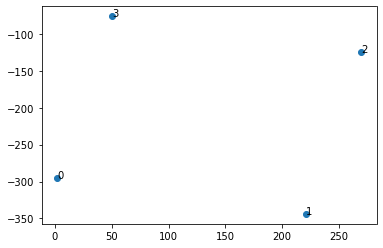

In [ ]:
display_closestwords_tsnescatterplot(model, '2')

In [ ]:
doc_tags = list(model.docvecs.doctags.keys())
print(doc_tags)
X = model[doc_tags]
print(X)

['0', '1', '2', '3']
[[ 1.2341797  -0.08278949  1.0448277   0.65457493  4.12156    -0.71586055
   1.8818611  -2.0306568  -0.38252074  0.58733755 -1.3059788  -3.7312086
   0.41353038  2.222112    0.08293577  1.6663697   0.29283676 -4.164214
  -5.5874176  -1.6762513   2.787369   -0.748923    2.987644    2.5212312
  -0.540748    1.2589462  -0.9413058   0.572643    3.3864434   2.2953825 ]
 [-0.36324072 -0.15500511 -0.07331314 -1.5553591   2.6786392  -1.6228952
   0.3447591  -2.1890554   0.24665226  2.0626416   0.06700604 -3.3800023
   0.91131645  3.2815866  -0.7061339  -1.0349281  -1.0764356  -2.6465626
  -5.2483687  -1.6176956   3.1422384   0.73564285  4.07617     1.9399142
  -0.28866482  2.5168383  -1.2533495  -1.2611943   4.4827523   2.333523  ]
 [-1.5308394  -0.23557843  0.6323117  -0.44717443  2.6845946  -2.680645
   0.24058746  0.4587441   0.52590126  2.607705    1.124441   -1.3890132
   0.36042503  1.3938576  -0.66166496 -0.49602845  1.2810297  -1.3626235
  -4.8327975  -1.3845669   

In [ ]:
tsne = TSNE(n_components=2, perplexity=5)
X_tsne = tsne.fit_transform(X)
df = pd.DataFrame(X_tsne, index=doc_tags, columns=['x', 'y'])
print(df)

            x           y
0  146.652634 -576.165283
1  373.328033 -149.180832
2  473.473877 -476.006134
3   46.506767 -249.339981


In [ ]:
df.to_csv('doc2vec.csv')

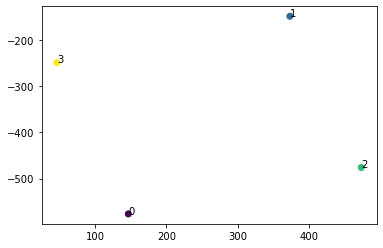

In [ ]:
plt.scatter(df['x'], df['y'], c=range(4))
for i in df.index:
    plt.text(df['x'][i], df['y'][i],i)
plt.show()

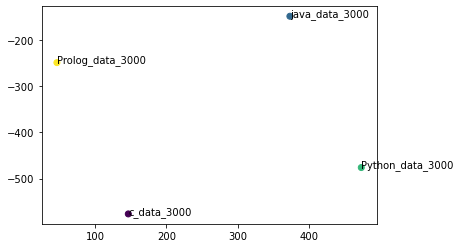

In [ ]:
plt.scatter(df['x'], df['y'], c=range(4))
for i in df.index:
    plt.text(df['x'][i], df['y'][i],Data_root[int(i)])
plt.show()

In [ ]:
df_1.index

Index(['0', '1', '2', '3'], dtype='object')

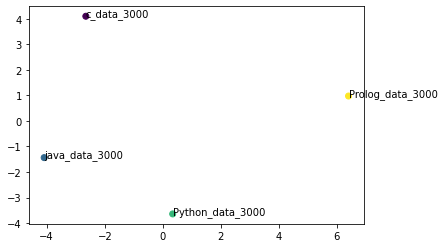

In [ ]:
plt.scatter(df_1['x'], df_1['y'], c=range(4))
for i in df_1.index:
    plt.text(df_1['x'][i], df_1['y'][i],Data_root[int(i)])
plt.show()

**Figure 5. Survey-based distribution of learners’ perceived difficulty and ease across programming paradigms**

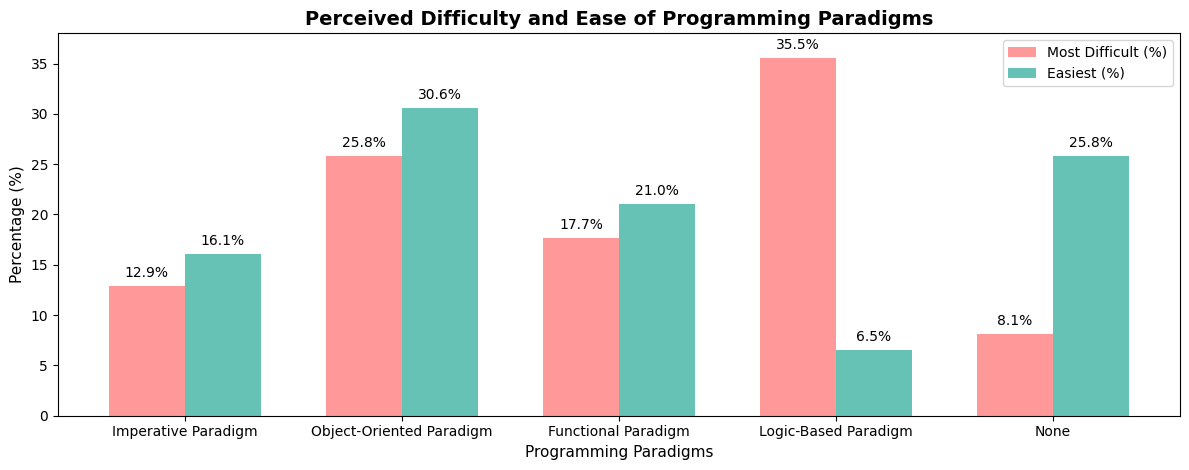

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Items (horizontal axis)
categories = [
    "Imperative Paradigm",
    "Object-Oriented Paradigm",
    "Functional Paradigm",
    "Logic-Based Paradigm",
    "None",
]

# 2) Survey figures (enter values ​​as is)
most_difficult = np.array([12.9, 25.8, 17.7, 35.5, 8.1])
easiest       = np.array([16.1, 30.6, 21.0,  6.5, 25.8])

# 3) Bar position/width
x = np.arange(len(categories))
width = 0.35

# 4) drawing graphs
fig, ax = plt.subplots(figsize=(12, 4.8))

bars1 = ax.bar(
    x - width/2, most_difficult, width,
    label="Most Difficult (%)",
    color="#ff9999"
)
bars2 = ax.bar(
    x + width/2, easiest, width,
    label="Easiest (%)",
    color="#66c2b4"
)

# 5) Title/Axis/Tickmark
ax.set_title("Perceived Difficulty and Ease of Programming Paradigms", fontsize=14, weight="bold")
ax.set_xlabel("Programming Paradigms", fontsize=11)
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0)
ax.set_ylim(0, 38)  # 35.5% 위에 여백 주기

# 6) legend
ax.legend(loc="upper right")

# 7) Display the value (%) above the bar
def add_labels(bars):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2, h + 0.6,
            f"{h:.1f}%",
            ha="center", va="bottom", fontsize=10
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()

# 8) save
plt.savefig("perceived_difficulty_ease.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 8. Comparison of perceived learning challenges and instructional demands across pro-gramming paradigms based on survey responses.**

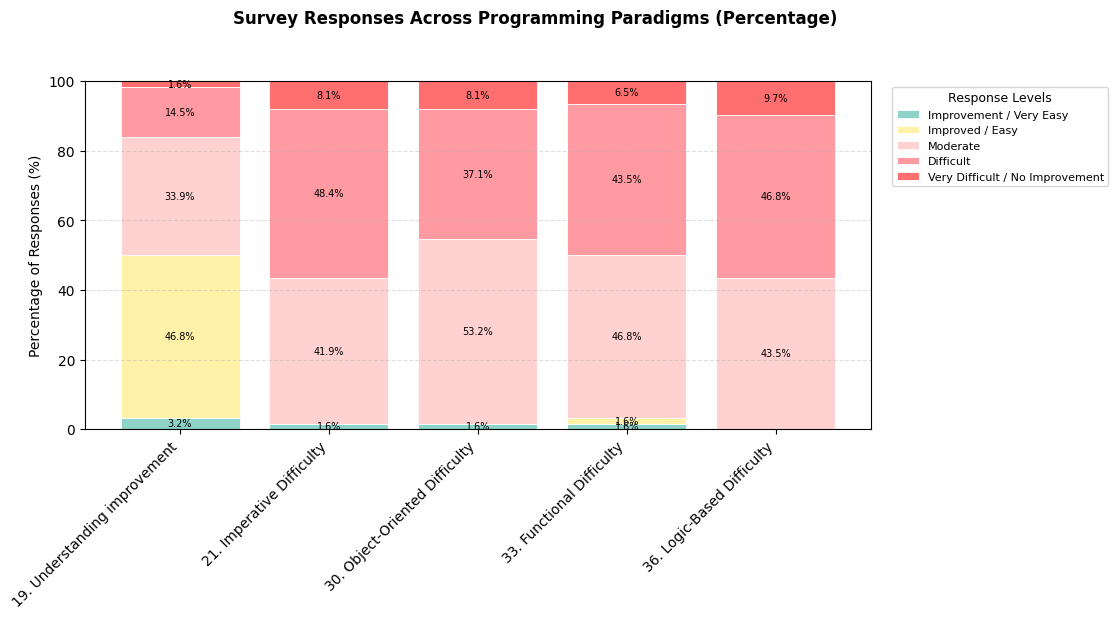

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

items = [
    "19. Understanding improvement",
    "21. Imperative Difficulty",
    "30. Object-Oriented Difficulty",
    "33. Functional Difficulty",
    "36. Logic-Based Difficulty",
]

levels = [
    "Improvement / Very Easy",
    "Improved / Easy",
    "Moderate",
    "Difficult",
    "Very Difficult / No Improvement",
]

data = np.array([
    [3.2, 46.8, 33.9, 14.5, 1.6],
    [1.6, 0.0, 41.9, 48.4, 8.1],
    [1.6, 0.0, 53.2, 37.1, 8.1],
    [1.6, 1.6, 46.8, 43.5, 6.5],
    [0.0, 0.0, 43.5, 46.8, 9.7],
])

colors = ["#8dd3c7", "#fff2a8", "#ffd1d1", "#ff9aa2", "#ff6f6f"]

# Figure size + top margin
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle(
    "Survey Responses Across Programming Paradigms (Percentage)",
    fontsize=12, fontweight="bold", y=0.98  # Move y up to secure title space
)

x = np.arange(len(items))
bottom = np.zeros(len(items))

for i, (lvl, col) in enumerate(zip(levels, colors)):
    ax.bar(
        x, data[:, i],
        bottom=bottom,
        label=lvl,
        color=col,
        edgecolor="white",
        linewidth=0.6
    )
    bottom += data[:, i]

ax.set_ylabel("Percentage of Responses (%)")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha="right")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

# legend
ax.legend(
    title="Response Levels",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

# percent label
for i in range(len(items)):
    cum = 0
    for j in range(len(levels)):
        val = data[i, j]
        if val > 0:
            ax.text(x[i], cum + val/2, f"{val:.1f}%", ha="center", va="center", fontsize=7)
        cum += val

# Leave a space for the title and also a space for the right (legend)
fig.subplots_adjust(top=0.86, right=0.78, bottom=0.28)

# save
plt.savefig(
    "survey_responses_stacked_100_NO_CROP.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.5
)

plt.show()

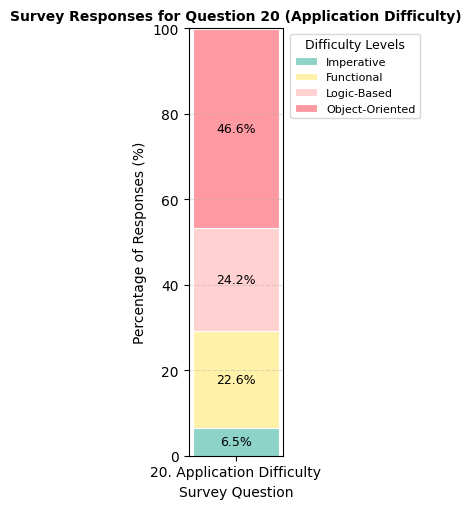

In [ ]:
import matplotlib.pyplot as plt

# =========================
# 1) Survey items
# =========================
x_label = ["20. Application Difficulty"]

# =========================
# 2) 범례(아래→위)
# =========================
levels = ["Imperative", "Functional", "Logic-Based", "Object-Oriented"]

# =========================
# 3) Enter numerical value (%)
# =========================
values = [6.5, 22.6, 24.2, 46.6]   # 합 = 100

# =========================
# 4) color
# =========================
colors = ["#8dd3c7", "#fff2a8", "#ffd1d1", "#ff9aa2"]

# =========================
# 5) graph
# =========================
fig, ax = plt.subplots(figsize=(3.2, 5.2))

bottom = 0
bars = []
for lvl, val, col in zip(levels, values, colors):
    b = ax.bar(
        x_label, val,
        bottom=bottom,
        color=col,
        edgecolor="white",
        linewidth=0.8,
        label=lvl
    )
    bars.append(b)

    # Center % label
    ax.text(
        0, bottom + val / 2,
        f"{val:.1f}%",
        ha="center", va="center",
        fontsize=9
    )
    bottom += val

# =========================
# 6) style
# =========================
ax.set_title("Survey Responses for Question 20 (Application Difficulty)", fontsize=10, weight="bold")
ax.set_ylabel("Percentage of Responses (%)")
ax.set_xlabel("Survey Question")
ax.set_ylim(0, 100)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

# Legend to the right
ax.legend(
    title="Difficulty Levels",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

plt.tight_layout()

# save
plt.savefig("Q20_application_difficulty_stacked.png", dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()

**Figure 7. Distribution of Stack Overflow question types (Problem, How-To, Other) across four programming languages based on rule-based classification**

In [ ]:
import os
import re
from collections import Counter
import pandas as pd

# Folder path where the question list is saved
corpus_folder = '/content/drive/MyDrive/four programming/four programming_Q_list'

# Question list file by language (3000 questions per file, one line = one question)
lang_files = {
    "Python": "Python_data_Q_list.txt",
    "Java": "java_data_Q_list.txt",
    "C": "C_data_Q_list.txt",
    "Prolog": "Prolog_data_Q_list.txt",
}

# English keyword patterns for identifying How To questions
HOWTO_PATTERNS = [
    r"\bhow to\b",
    r"\bhow do i\b",
    r"\bhow can i\b",
    r"\bhow should i\b",
    r"\bhow would i\b",
    r"\bhow\b.*\bto\b"
]

# English keyword patterns to determine problem questions
PROBLEM_PATTERNS = [
    r"\berror\b",
    r"\bexception\b",
    r"\btraceback\b",
    r"\bbug\b",
    r"\bfail(?:ed|s)?\b",
    r"\bcrash(?:ed|es)?\b",
    r"\bdoesn't work\b",
    r"\bdoes not work\b",
    r"\bnot working\b",
    r"\bsegmentation fault\b",
    r"\bnullpointerexception\b",
    r"\bsyntaxerror\b",
    r"\btypeerror\b",
    r"\bvalueerror\b",
    r"\bindexerror\b",
    r"\bkeyerror\b",
    r"\bruntimeerror\b"
]

# Compile regular expressions (case insensitive)
howto_re = re.compile("|".join(HOWTO_PATTERNS), re.IGNORECASE)
problem_re = re.compile("|".join(PROBLEM_PATTERNS), re.IGNORECASE)

def classify_question(question):
    """
    Exclusively categorize one question.
    Priority: Problem → How To → Other

    """
    q = question.strip().lower()

    # Problem if there are keywords related to error/exception/execution failure
    if problem_re.search(q):
        return "Problem"

    # How To is a method question such as how to / how do I / how can I
    if howto_re.search(q):
        return "How To"

    # Other if the above two conditions are not met
    return "Other"

results = []

for language, filename in lang_files.items():
    file_path = os.path.join(corpus_folder, filename)

    # Read the question file (remove blank lines)
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        questions = [line.strip() for line in f if line.strip()]

    # Count by question type
    counts = Counter(classify_question(q) for q in questions)

    # Save results by language
    results.append({
        "Language": language,
        "Other": counts["Other"],
        "How To": counts["How To"],
        "Problem": counts["Problem"]
    })

# Organize the results into a data frame
df = pd.DataFrame(results)
df

,Language,Other,How To,Problem
0,Python,2001,718,281
1,Java,1885,697,418
2,C,2165,499,336
3,Prolog,2228,613,159


In [ ]:
import pandas as pd

data = {
    "Language": ["Python", "Java", "C", "Prolog"],
    "Other": [2001, 1885, 2165, 2228],
    "How To": [718, 697, 499, 613],
    "Problem": [281, 418, 336, 159],
}

df = pd.DataFrame(data)

df["Other Questions (%)"] = (df["Other"] / 3000 * 100).round(0).astype(int)
df["How To Questions (%)"] = (df["How To"] / 3000 * 100).round(0).astype(int)
df["Problem Questions (%)"] = (df["Problem"] / 3000 * 100).round(0).astype(int)

df[["Language", "Other Questions (%)", "How To Questions (%)", "Problem Questions (%)"]]

,Language,Other Questions (%),How To Questions (%),Problem Questions (%)
0,Python,67,24,9
1,Java,63,23,14
2,C,72,17,11
3,Prolog,74,20,5


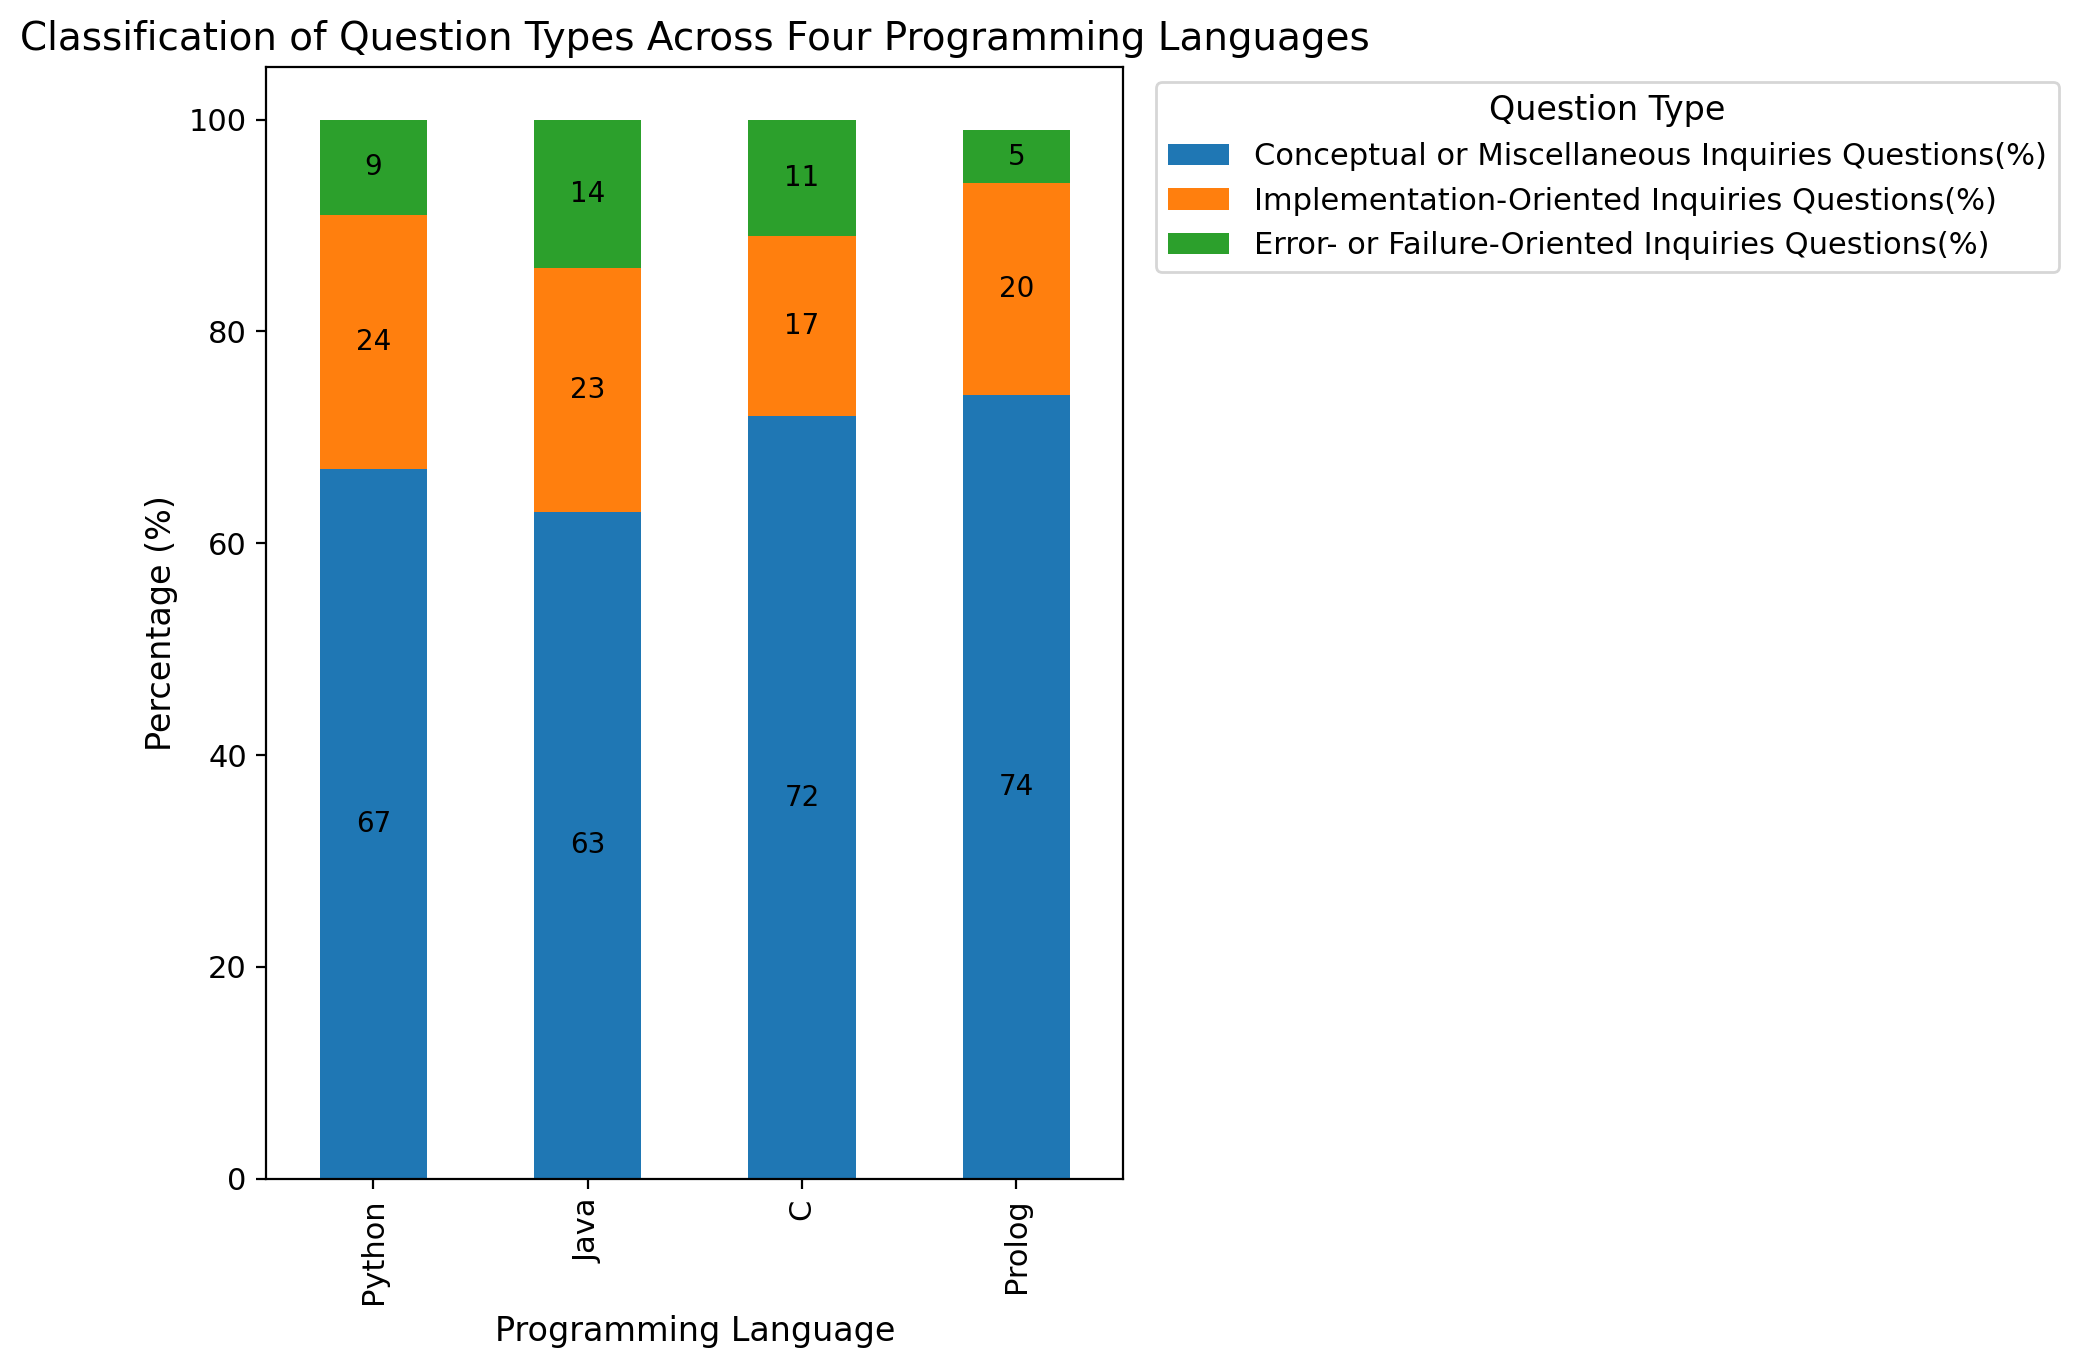

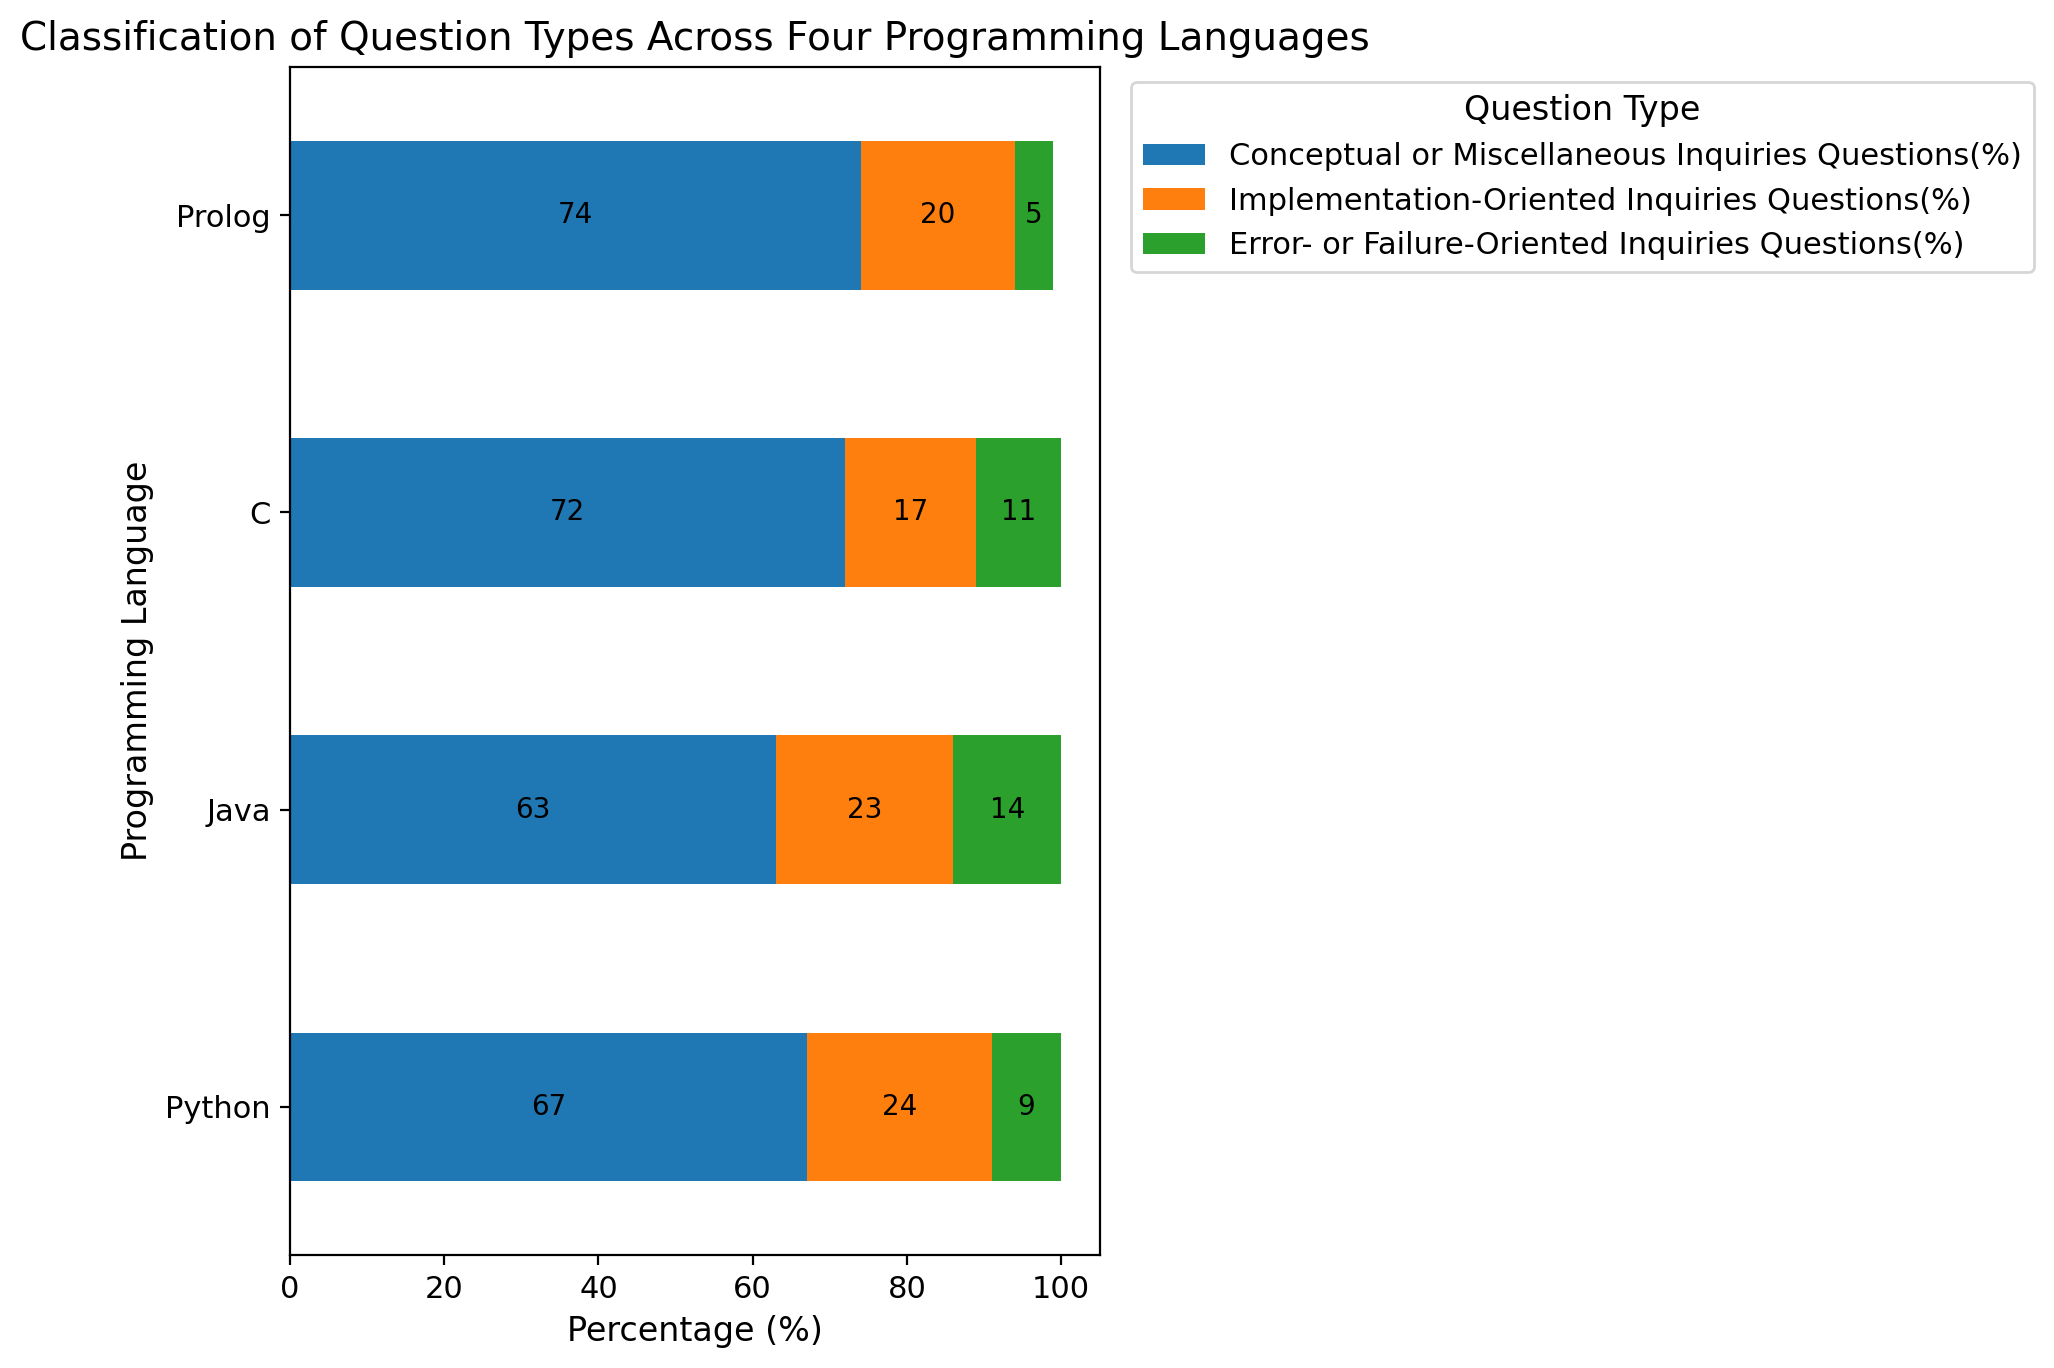

Saved figures to: /content/drive/MyDrive/figures


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --------------------------------------------------
# 1) Data
# --------------------------------------------------
data = {
    'Language': ['Python', 'Java', 'C', 'Prolog'],
    'Conceptual or Miscellaneous Inquiries Questions(%)': [67, 63, 72, 74],
    'Implementation-Oriented Inquiries Questions(%)': [24, 23, 17, 20],
    'Error- or Failure-Oriented Inquiries Questions(%)': [9, 14, 11, 5]
}

df = pd.DataFrame(data)

# --------------------------------------------------
# 2) Matplotlib settings
# --------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# --------------------------------------------------
# 3) Save path
# --------------------------------------------------
save_dir = "/content/drive/MyDrive/figures"
os.makedirs(save_dir, exist_ok=True)

# ==================================================
# (a) Vertical stacked bar chart
# ==================================================
fig, ax = plt.subplots(figsize=(10, 7))

df.plot(
    x='Language',
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title('Classification of Question Types Across Four Programming Languages')
ax.set_xlabel('Programming Language')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Question Type', bbox_to_anchor=(1.02, 1), loc='upper left')

# numeric display
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=10)

fig.tight_layout()

# Save
fig.savefig(os.path.join(save_dir, 'Figure_Question_Type_StackedBar.pdf'),
            bbox_inches='tight')
fig.savefig(os.path.join(save_dir, 'Figure_Question_Type_StackedBar_600dpi.png'),
            dpi=600, bbox_inches='tight')

plt.show()

# ==================================================
# (b) Horizontal stacked bar chart
# ==================================================
fig, ax = plt.subplots(figsize=(10, 7))

df.plot(
    x='Language',
    kind='barh',
    stacked=True,
    ax=ax
)

ax.set_title('Classification of Question Types Across Four Programming Languages')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Programming Language')
ax.legend(title='Question Type', bbox_to_anchor=(1.02, 1), loc='upper left')

# numeric display
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=10)

fig.tight_layout()

# Save
fig.savefig(os.path.join(save_dir, 'Figure_Question_Type_StackedBarH.pdf'),
            bbox_inches='tight')
fig.savefig(os.path.join(save_dir, 'Figure_Question_Type_StackedBarH_600dpi.png'),
            dpi=600, bbox_inches='tight')

plt.show()

print("Saved figures to:", os.path.abspath(save_dir))

In [ ]:
import os
import re
from collections import Counter
import pandas as pd

corpus_folder = '/content/drive/MyDrive/four programming/four programming_Q_list'

lang_files = {
    "Python": "Python_data_Q_list.txt",
    "Java": "java_data_Q_list.txt",
    "C": "C_data_Q_list.txt",
    "Prolog": "Prolog_data_Q_list.txt",
}

HOWTO_PATTERNS = [
    r"\bhow to\b",
    r"\bhow do i\b",
    r"\bhow can i\b",
    r"\bhow should i\b",
    r"\bhow would i\b",
    r"\bhow\b.*\bto\b"
]

PROBLEM_PATTERNS = [
    r"\berror\b",
    r"\bexception\b",
    r"\btraceback\b",
    r"\bbug\b",
    r"\bfail(?:ed|s)?\b",
    r"\bcrash(?:ed|es)?\b",
    r"\bdoesn't work\b",
    r"\bdoes not work\b",
    r"\bnot working\b",
    r"\bsegmentation fault\b",
    r"\bnullpointerexception\b",
    r"\bsyntaxerror\b",
    r"\btypeerror\b",
    r"\bvalueerror\b",
    r"\bindexerror\b",
    r"\bkeyerror\b",
    r"\bruntimeerror\b"
]

howto_re = re.compile("|".join(HOWTO_PATTERNS), re.IGNORECASE)
problem_re = re.compile("|".join(PROBLEM_PATTERNS), re.IGNORECASE)

def classify_question(question):
    q = question.strip().lower()
    if problem_re.search(q):
        return "Problem"
    if howto_re.search(q):
        return "How To"
    return "Other"

def read_questions(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        return [line.strip() for line in f if line.strip()]

def get_one_sample_per_type(questions):
    samples = {"Other": None, "How To": None, "Problem": None}
    for q in questions:
        label = classify_question(q)
        if samples[label] is None:
            samples[label] = q
        if all(samples.values()):
            break
    return samples

def matched_keyword(text, patterns):
    if not text:
        return None
    t = text.lower()
    for p in patterns:
        if re.search(p, t, re.IGNORECASE):
            return p
    return None

rows = []

for language, filename in lang_files.items():
    file_path = os.path.join(corpus_folder, filename)
    questions = read_questions(file_path)

    samples = get_one_sample_per_type(questions)

    rows.append({
        "Language": language,
        "Other Sample": samples["Other"],
        "How To Sample": samples["How To"],
        "How To Matched Pattern": matched_keyword(samples["How To"], HOWTO_PATTERNS),
        "Problem Sample": samples["Problem"],
        "Problem Matched Pattern": matched_keyword(samples["Problem"], PROBLEM_PATTERNS),
    })

df_samples_with_patterns = pd.DataFrame(rows)
df_samples_with_patterns

,Language,Other Sample,How To Sample,How To Matched Pattern,Problem Sample,Problem Matched Pattern
0,Python,My registration code returns incorrect even if...,How to transpose (transform) Pandas DataFrame ...,\bhow to\b,Importing gcsfs in datalab is giving an error,\berror\b
1,Java,My app is crashing after I clicked the call bu...,How to extract both positive and negative inte...,\bhow to\b,Crash occurring on some devices and not on oth...,\bexception\b
2,C,Cannot display all the element of my array in C?,how to uninstall MinGW and make cygwin 'make' ...,\bhow to\b,Segmentation fault (core dumped) in C code.,\bsegmentation fault\b
3,Prolog,What is the simple way to find the max length ...,"How to ""return"" two values in prolog",\bhow to\b,Prolog String-Intensive Algorithm Crashes,\bcrash(?:ed|es)?\b


In [ ]:
import os
import re
from collections import Counter

corpus_folder = '/content/drive/MyDrive/four programming/four programming_Q_list'

lang_files = {
    "Python": "Python_data_Q_list.txt",
    "Java": "java_data_Q_list.txt",
    "C": "C_data_Q_list.txt",
    "Prolog": "Prolog_data_Q_list.txt",
}

HOWTO_PATTERNS = [
    r"\bhow to\b",
    r"\bhow do i\b",
    r"\bhow can i\b",
    r"\bhow should i\b",
    r"\bhow would i\b",
    r"\bhow\b.*\bto\b"
]

PROBLEM_PATTERNS = [
    r"\berror\b",
    r"\bexception\b",
    r"\btraceback\b",
    r"\bbug\b",
    r"\bfail(?:ed|s)?\b",
    r"\bcrash(?:ed|es)?\b",
    r"\bdoesn't work\b",
    r"\bdoes not work\b",
    r"\bnot working\b",
    r"\bsegmentation fault\b",
    r"\bnullpointerexception\b",
    r"\bsyntaxerror\b",
    r"\btypeerror\b",
    r"\bvalueerror\b",
    r"\bindexerror\b",
    r"\bkeyerror\b",
    r"\bruntimeerror\b"
]

howto_re = re.compile("|".join(HOWTO_PATTERNS), re.IGNORECASE)
problem_re = re.compile("|".join(PROBLEM_PATTERNS), re.IGNORECASE)

def classify_question(question):
    q = question.strip().lower()
    if problem_re.search(q):
        return "Problem"
    if howto_re.search(q):
        return "How To"
    return "Other"

def read_questions(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        return [line.strip() for line in f if line.strip()]

def get_one_sample_per_type(questions):
    samples = {"Other": None, "How To": None, "Problem": None}
    for q in questions:
        label = classify_question(q)
        if samples[label] is None:
            samples[label] = q
        if all(samples.values()):
            break
    return samples

def matched_keyword(text, patterns):
    if not text:
        return None
    t = text.lower()
    for p in patterns:
        if re.search(p, t, re.IGNORECASE):
            return p
    return None

# -------------------------
# 줄 단위 출력
# -------------------------
for language, filename in lang_files.items():
    file_path = os.path.join(corpus_folder, filename)
    questions = read_questions(file_path)

    samples = get_one_sample_per_type(questions)

    print(f"Language: {language}")
    print(f"Other sample:")
    print(f"  {samples['Other']}")
    print()

    print(f"How To sample:")
    print(f"  {samples['How To']}")
    print(f"  matched pattern: {matched_keyword(samples['How To'], HOWTO_PATTERNS)}")
    print()

    print(f"Problem sample:")
    print(f"  {samples['Problem']}")
    print(f"  matched pattern: {matched_keyword(samples['Problem'], PROBLEM_PATTERNS)}")
    print("\n" + "-" * 60 + "\n")

Language: Python
Other sample:
  My registration code returns incorrect even if the details are correct

How To sample:
  How to transpose (transform) Pandas DataFrame with 2 columns (values should become new columns)?
  matched pattern: \bhow to\b

Problem sample:
  Importing gcsfs in datalab is giving an error
  matched pattern: \berror\b

------------------------------------------------------------

Language: Java
Other sample:
  My app is crashing after I clicked the call buttton I am a starter in Android Studio, my app works fine but crasher every time i click the call button

How To sample:
  How to extract both positive and negative integers from a string input in java which has the input pattern as given below?
  matched pattern: \bhow to\b

Problem sample:
  Crash occurring on some devices and not on others with Index Out Of Bounds exception | Android I have a really huge problems.
  matched pattern: \bexception\b

------------------------------------------------------------



**Verification**

In [ ]:
import os
import re
import random
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
corpus_folder = '/content/drive/MyDrive/four programming/four programming_Q_list'
save_dir = '/content/drive/MyDrive/four programming/validation'
os.makedirs(save_dir, exist_ok=True)

lang_files = {
    "Python": "Python_data_Q_list.txt",
    "Java": "java_data_Q_list.txt",
    "C": "C_data_Q_list.txt",
    "Prolog": "Prolog_data_Q_list.txt",
}

# -----------------------------
# Patterns (same as Figure 7)
# -----------------------------
HOWTO_PATTERNS = [
    r"\bhow to\b",
    r"\bhow do i\b",
    r"\bhow can i\b",
    r"\bhow should i\b",
    r"\bhow would i\b",
    r"\bhow\b.*\bto\b"
]

PROBLEM_PATTERNS = [
    r"\berror\b", r"\bexception\b", r"\btraceback\b", r"\bbug\b",
    r"\bfail(?:ed|s)?\b", r"\bcrash(?:ed|es)?\b",
    r"\bdoesn't work\b", r"\bdoes not work\b", r"\bnot working\b",
    r"\bsegmentation fault\b", r"\bnullpointerexception\b",
    r"\bsyntaxerror\b", r"\btypeerror\b", r"\bvalueerror\b",
    r"\bindexerror\b", r"\bkeyerror\b", r"\bruntimeerror\b"
]

howto_re = re.compile("|".join(HOWTO_PATTERNS), re.IGNORECASE)
problem_re = re.compile("|".join(PROBLEM_PATTERNS), re.IGNORECASE)

def classify_question(q):
    q = q.lower()
    if problem_re.search(q):
        return "Problem"
    if howto_re.search(q):
        return "How To"
    return "Other"

# -----------------------------
# Create validation CSV
# -----------------------------
for lang, fname in lang_files.items():
    with open(os.path.join(corpus_folder, fname), encoding="utf-8", errors="ignore") as f:
        questions = [q.strip() for q in f if q.strip()]

    sampled = random.sample(questions, 100)

    rows = []
    for q in sampled:
        auto = classify_question(q)
        rows.append({
            "question": q,
            "auto_label": auto,
            "human_label": auto   # ★ 처음엔 동일하게 채움
        })

    df = pd.DataFrame(rows)
    out_path = os.path.join(save_dir, f"validation_{lang}.csv")
    df.to_csv(out_path, index=False, encoding="utf-8-sig")

    print(f"Saved: {out_path}")

Saved: /content/drive/MyDrive/four programming/validation/validation_Python.csv
Saved: /content/drive/MyDrive/four programming/validation/validation_Java.csv
Saved: /content/drive/MyDrive/four programming/validation/validation_C.csv
Saved: /content/drive/MyDrive/four programming/validation/validation_Prolog.csv


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

validation_dir = '/content/drive/MyDrive/four programming/validation'

for lang in ["Python", "Java", "C", "Prolog"]:
    path = f"{validation_dir}/validation_{lang}.csv"
    df = pd.read_csv(path)

    y_true = df["human_label"]
    y_pred = df["auto_label"]

    print("\n" + "="*60)
    print(f"Validation results for {lang}")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print(classification_report(y_true, y_pred, digits=3))


Validation results for Python
Accuracy: 1.0
              precision    recall  f1-score   support

      How To      1.000     1.000     1.000        21
       Other      1.000     1.000     1.000        75
     Problem      1.000     1.000     1.000         4

    accuracy                          1.000       100
   macro avg      1.000     1.000     1.000       100
weighted avg      1.000     1.000     1.000       100


Validation results for Java
Accuracy: 1.0
              precision    recall  f1-score   support

      How To      1.000     1.000     1.000        28
       Other      1.000     1.000     1.000        55
     Problem      1.000     1.000     1.000        17

    accuracy                          1.000       100
   macro avg      1.000     1.000     1.000       100
weighted avg      1.000     1.000     1.000       100


Validation results for C
Accuracy: 1.0
              precision    recall  f1-score   support

      How To      1.000     1.000     1.000        11
 